# RL Evaluation & Visualisation


## Imports

In [139]:
from __future__ import annotations

import sys
import os
import warnings

# Add the repository root to sys.path so project modules can be imported
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path


# Consistent, presentation-ready style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

print('Imports OK')

Imports OK


<a id='section-1'></a>
## Section 1 — Setup & Run / Load Experiments

Edit the constants below to match the grid size and experiment configuration you
want to analyse.  The cell then checks whether log files already exist; if they
do not, it runs all three approaches via `compare_all()` and saves the results.

In [120]:
# ─────────────────────────────────────────────────────────────────────────────
# Configuration — edit these to match your experiment settings
# ─────────────────────────────────────────────────────────────────────────────

LOG_DIR      = Path('../logs/compare')   # must match --log-dir in compare_approaches.py
ENV_NAME = 'four_rooms'  # must match --env-name in compare_approaches.py
GRID_HEIGHT  = 11
GRID_WIDTH   = 11
N_EPISODES   = 300   # training episodes per approach
MAX_STEPS    = 1000   # max steps per episode
SEED         = 42

# GCRL contrastive-gamma: set to None to auto-scale from grid size
# (uses (H+W-2)/(H+W-1) — ensures E[delta] >= min-path so goal signal
# reaches the start state).  For 10x10 this gives ~0.947.  Override
# explicitly if you have walls or non-corner start/goal positions.
CONTRASTIVE_GAMMA = None  # None = auto-scaled in compare_approaches.py

# Derived constants
GOAL_STATE   = GRID_HEIGHT * GRID_WIDTH - 1   # bottom-right cell
START_STATE  = 0                               # top-left cell

APPROACHES = ['random', 'gcrl', 'rcrl', 'exdm']
LABELS = {
    'random': 'Random Baseline',
    'gcrl':   'GCRL (Contrastive RL)',
    'rcrl':   'RCRL (Reward-Conditioned)',
    'exdm':   'EXDM (Exploratory Diffusion Model)',
}
COLORS = {
    'random': '#e74c3c',
    'gcrl':   '#2ecc71',
    'rcrl':   '#3498db',
    'exdm':   '#9b59b6',
}

# ─────────────────────────────────────────────────────────────────────────────
# Run experiments
# Set FORCE_RERUN = True (default) to always re-run and overwrite existing logs.
# Set to False to reuse previously saved CSVs without re-running.
# ─────────────────────────────────────────────────────────────────────────────

FORCE_RERUN = True   # always overwrite logs with fresh results

def _logs_exist() -> bool:
    return all((LOG_DIR / ap / 'metrics.csv').exists() for ap in APPROACHES)


if FORCE_RERUN or not _logs_exist():
    print('Running experiments (logs will be overwritten) ...')
    print('(This may take a couple of minutes on a 5x5 grid.)\n')

    # Flush stale cached project modules so edits made between kernel restart
    # and this cell are always picked up.
    _proj = ('experiments', 'agents', 'environments', 'utils', 'mdp')
    for _m in list(sys.modules):
        if any(_m == p or _m.startswith(p + '.') for p in _proj):
            del sys.modules[_m]

    from experiments.compare_approaches import compare_all, parse_args

    _cg_args = ['--contrastive-gamma', str(CONTRASTIVE_GAMMA)] if CONTRASTIVE_GAMMA is not None else []
    args = parse_args([
        '--env',    ENV_NAME,
        '--height',      str(GRID_HEIGHT),
        '--width',       str(GRID_WIDTH),
        '--episodes',    str(N_EPISODES),
        '--max-steps',   str(MAX_STEPS),
        '--seed',        str(SEED),
        '--log-dir',     str(LOG_DIR),
        '--goal-state',  str(GOAL_STATE),
        '--start-state', str(START_STATE),
    ] + _cg_args)
    _results = compare_all(args)
    print('\nExperiments complete!')
else:
    print(f'Existing logs found in {LOG_DIR} — loading without re-running ...')


Running experiments (logs will be overwritten) ...
(This may take a couple of minutes on a 5x5 grid.)

[    0.0s] Episode      1 [train] | reward=    0.00 | steps= 1000
[    0.0s] Episode      2 [train] | reward=    0.00 | steps= 1000
[    0.0s] Episode      3 [train] | reward=    1.00 | steps=  845
[    0.0s] Episode      4 [train] | reward=    1.00 | steps=  786
[    0.0s] Episode      5 [train] | reward=    1.00 | steps=  733
[    0.0s] Episode      6 [train] | reward=    0.00 | steps= 1000
[    0.0s] Episode      7 [train] | reward=    0.00 | steps= 1000
[    0.0s] Episode      8 [train] | reward=    0.00 | steps= 1000
[    0.0s] Episode      9 [train] | reward=    1.00 | steps=  279
[    0.0s] Episode     10 [train] | reward=    0.00 | steps= 1000
[    0.0s] Episode     11 [train] | reward=    1.00 | steps=  683
[    0.0s] Episode     12 [train] | reward=    1.00 | steps=  200
[    0.0s] Episode     13 [train] | reward=    0.00 | steps= 1000
[    0.0s] Episode     14 [train] | rew

### Comparison Table

Summarise the key metrics for each approach from the saved CSVs.

In [121]:
# Load all metrics CSVs
dfs: dict[str, pd.DataFrame] = {}
for ap in APPROACHES:
    path = LOG_DIR / ap / 'metrics.csv'
    if path.exists():
        dfs[ap] = pd.read_csv(path)
    else:
        print(f'WARNING: {path} not found — skipping {ap}')


def _safe_mean(series: pd.Series) -> str:
    return f'{series.mean():.4f}' if len(series) > 0 else 'N/A'


rows = []
for ap in APPROACHES:
    if ap not in dfs:
        continue
    df   = dfs[ap]
    tr   = df[df['mode'] == 'train']['total_reward']
    ev   = df[df['mode'] == 'eval']['total_reward']
    k    = max(1, len(tr) // 10)
    last = tr.iloc[-k:]
    rows.append({
        'Approach':          LABELS[ap],
        'Mean Train Reward': _safe_mean(tr),
        'Last-10% Reward':   _safe_mean(last),
        'Mean Eval Reward':  _safe_mean(ev) if len(ev) > 0 else 'N/A',
        'Train Episodes':    len(tr),
        'Eval Episodes':     len(ev),
    })

summary = pd.DataFrame(rows).set_index('Approach')
print('COMPARISON TABLE')
print('=' * 72)
display(summary)

COMPARISON TABLE


,Mean Train Reward,Last-10% Reward,Mean Eval Reward,Train Episodes,Eval Episodes
Approach,,,,,
Random Baseline,0.5567,0.5333,0.3333,300,6
GCRL (Contrastive RL),0.9267,1.0000,1.0000,300,6
RCRL (Reward-Conditioned),0.9800,1.0000,1.0000,300,6
EXDM (Exploratory Diffusion Model),0.5467,0.0000,0.0000,300,6


<a id='section-2'></a>
## Section 2 — Reward over Time

Each subplot shows:
- **Faint line** — raw episode reward
- **Solid line** — rolling mean (window = `SMOOTH`)
- **Shaded band** — rolling ±1 standard deviation
- **◆ markers** — evaluation / exploitation episodes

The overlay plot shows smoothed rewards for all three approaches on the same axes
for direct comparison.

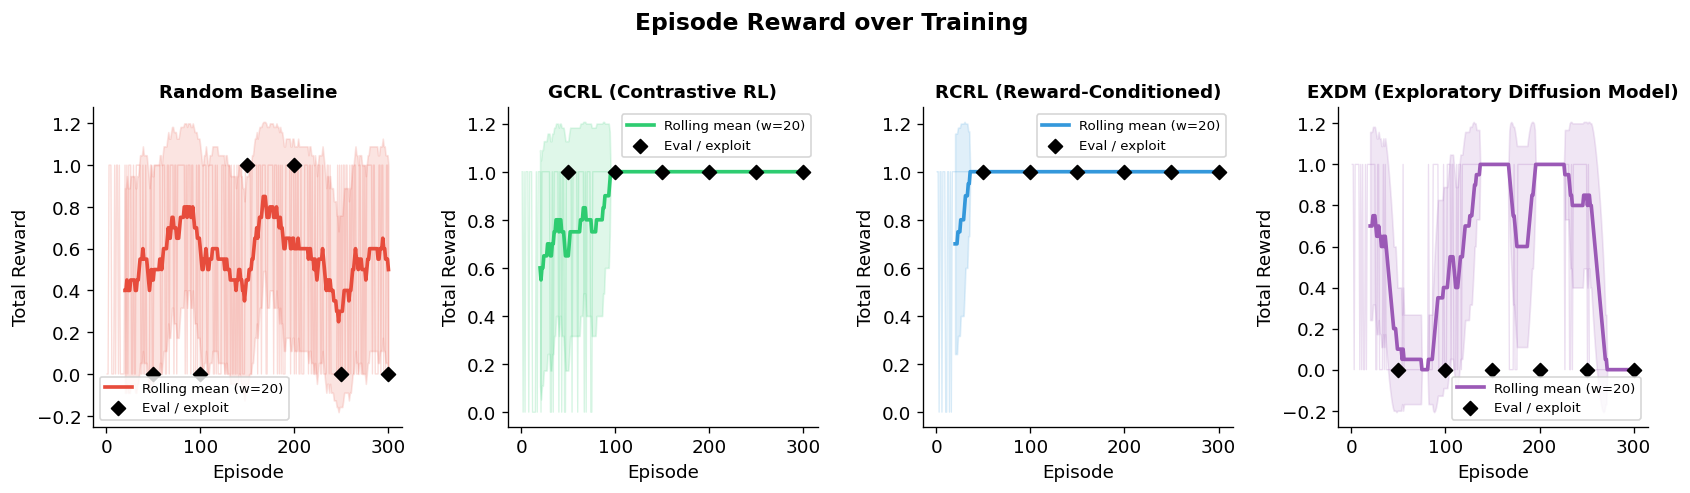

Saved → ../logs/compare/reward_over_time_subplots.png


In [140]:
SMOOTH = 20   # rolling-mean window width

fig, axes = plt.subplots(1, len(APPROACHES), figsize=(14, 4), sharey=False)
fig.suptitle('Episode Reward over Training', fontsize=14, fontweight='bold', y=1.02)

for ax, ap in zip(axes, APPROACHES):
    if ap not in dfs:
        ax.set_visible(False)
        continue

    df    = dfs[ap]
    train = df[df['mode'] == 'train'].reset_index(drop=True)
    evdf  = df[df['mode'] == 'eval'].reset_index(drop=True)

    ep  = train['episode']
    rew = train['total_reward']
    mu  = rew.rolling(SMOOTH, min_periods=SMOOTH).mean()
    sd  = rew.rolling(SMOOTH, min_periods=SMOOTH).std(ddof=0).fillna(0)

    # Raw rewards (faint background)
    ax.plot(ep, rew, alpha=0.20, color=COLORS[ap], linewidth=0.8)
    # Rolling mean
    ax.plot(ep, mu, color=COLORS[ap], linewidth=2.2, label=f'Rolling mean (w={SMOOTH})')
    # ±1 std band
    ax.fill_between(ep, mu - sd, mu + sd, alpha=0.15, color=COLORS[ap])

    # Evaluation / exploitation checkpoints
    if len(evdf) > 0:
        ax.scatter(
            evdf['episode'], evdf['total_reward'],
            marker='D', s=35, color='black', zorder=5, label='Eval / exploit',
        )

    ax.set_title(LABELS[ap], fontsize=11, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend(fontsize=8)

plt.tight_layout()
LOG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(LOG_DIR / 'reward_over_time_subplots.png', bbox_inches='tight')
plt.show()
print(f'Saved → {LOG_DIR / "reward_over_time_subplots.png"}')

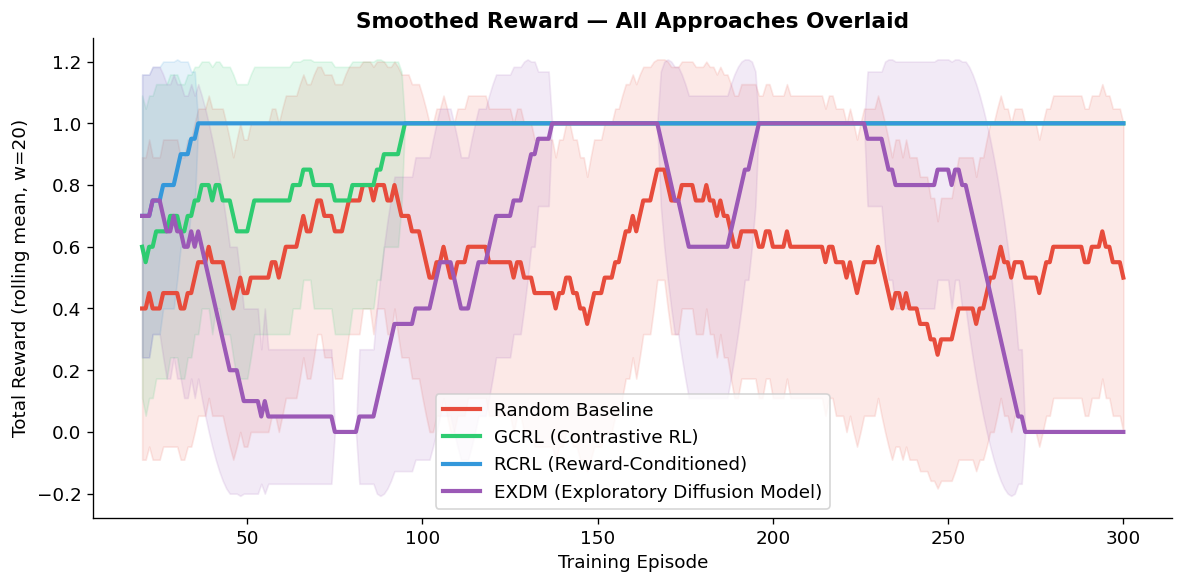

Saved → ../logs/compare/reward_over_time_overlay.png


In [141]:
# ─── Overlay comparison ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Smoothed Reward — All Approaches Overlaid', fontsize=13, fontweight='bold')

for ap in APPROACHES:
    if ap not in dfs:
        continue
    train = dfs[ap][dfs[ap]['mode'] == 'train'].reset_index(drop=True)
    ep    = train['episode']
    mu    = train['total_reward'].rolling(SMOOTH, min_periods=SMOOTH).mean()
    sd    = train['total_reward'].rolling(SMOOTH, min_periods=SMOOTH).std(ddof=0).fillna(0)

    ax.plot(ep, mu, color=COLORS[ap], linewidth=2.5, label=LABELS[ap])
    ax.fill_between(ep, mu - sd, mu + sd, alpha=0.12, color=COLORS[ap])

ax.set_xlabel('Training Episode')
ax.set_ylabel(f'Total Reward (rolling mean, w={SMOOTH})')
ax.legend()
plt.tight_layout()
plt.savefig(LOG_DIR / 'reward_over_time_overlay.png', bbox_inches='tight')
plt.show()
print(f'Saved → {LOG_DIR / "reward_over_time_overlay.png"}')

<a id='section-3'></a>
## Section 3 — Epsilon (ε) Decay over Training

- **Random Baseline**: ε = 1.0 throughout (always random, no learning).
- **RCRL**: ε is decayed multiplicatively each episode; values are read from the
  `epsilon` column of the CSV (logged by `Logger`).  If the column is absent the
  curve is re-computed analytically from the default hyperparameters.
- **GCRL**: does not use ε-greedy — it uses a softmax temperature τ instead.
  This plot therefore omits GCRL and notes the difference.

In [124]:
# # Default RCRL hyperparameters (used only when epsilon column is absent)
# EPS_INIT  = 1.0
# EPS_MIN   = 0.05
# EPS_DECAY = 0.995

# fig, ax = plt.subplots(figsize=(9, 4))
# ax.set_title('Exploration Schedule (ε) over Training', fontsize=13, fontweight='bold')

# plotted_any = False

# for ap in APPROACHES:
#     if ap not in dfs:
#         continue

#     train = dfs[ap][dfs[ap]['mode'] == 'train'].reset_index(drop=True)

#     if ap == 'random':
#         ax.plot(
#             train['episode'], np.ones(len(train)),
#             color=COLORS[ap], linewidth=2, linestyle='--',
#             label=f"{LABELS[ap]}  (ε = 1.0, always random)",
#         )
#         plotted_any = True

#     elif ap == 'rcrl':
#         eps_col = pd.to_numeric(train.get('epsilon', pd.Series(dtype=float)), errors='coerce')
#         valid   = eps_col.notna() & (eps_col > 0)
#         if valid.any():
#             ax.plot(
#                 train['episode'][valid], eps_col[valid],
#                 color=COLORS[ap], linewidth=2,
#                 label=f"{LABELS[ap]}  (logged ε)",
#             )
#         else:
#             # Fall back to analytic computation
#             n   = len(train)
#             eps = np.maximum(EPS_MIN, EPS_INIT * EPS_DECAY ** np.arange(n))
#             ax.plot(
#                 train['episode'], eps,
#                 color=COLORS[ap], linewidth=2,
#                 label=f"{LABELS[ap]}  (analytic: ε₀={EPS_INIT}, decay={EPS_DECAY})",
#             )
#         plotted_any = True

#     # gcrl: no epsilon — handled by the annotation below

# if plotted_any:
#     ax.set_xlabel('Training Episode')
#     ax.set_ylabel('Epsilon (ε)')
#     ax.set_ylim(-0.05, 1.15)
#     ax.legend()
#     ax.annotate(
#         'GCRL uses softmax temperature τ instead of ε — not shown here.',
#         xy=(0.02, 0.06), xycoords='axes fraction',
#         fontsize=9, color='grey', fontstyle='italic',
#     )
#     plt.tight_layout()
#     plt.savefig(LOG_DIR / 'epsilon_decay.png', bbox_inches='tight')
#     plt.show()
#     print(f'Saved → {LOG_DIR / "epsilon_decay.png"}')
# else:
#     plt.close()
#     print('No data available for epsilon plot.')

<a id='section-4'></a>
## Section 4 — Agent Trajectory Visualisation

Each panel shows the **last evaluation / exploitation episode** for one approach:

- **Background heatmap** — per-cell visit count (blue intensity)
- **Blue arrows** — step-by-step path taken by the agent
- **🟢 Green dot** — start position
- **⭐ Red star** — goal position

Repeated transitions are drawn once (with a thicker arrow) to keep the plot readable.

In [142]:
# Load trajectory CSVs
traj_dfs: dict[str, pd.DataFrame] = {}
for ap in APPROACHES:
    path = LOG_DIR / ap / 'trajectory.csv'
    if path.exists():
        traj_dfs[ap] = pd.read_csv(path)
        print(f'Loaded trajectory for {LABELS[ap]}  ({len(traj_dfs[ap])} steps)')
    else:
        print(f'No trajectory file found for {ap}  ({path})')

Loaded trajectory for Random Baseline  (1000 steps)
Loaded trajectory for GCRL (Contrastive RL)  (304 steps)
Loaded trajectory for RCRL (Reward-Conditioned)  (21 steps)
Loaded trajectory for EXDM (Exploratory Diffusion Model)  (1000 steps)


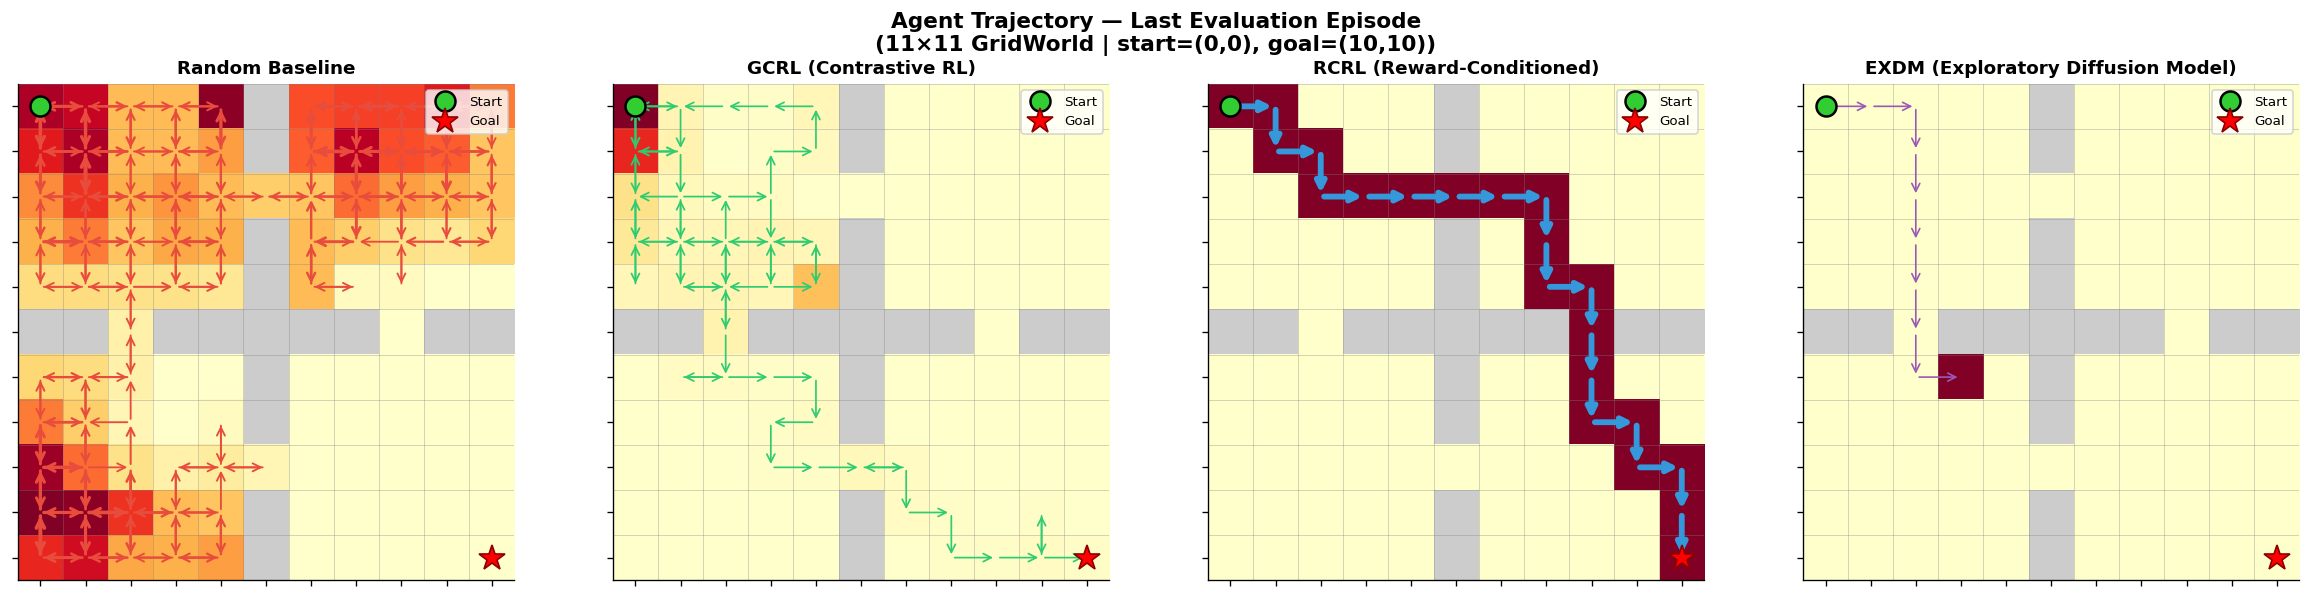

Saved → ../logs/compare/trajectories.png


In [143]:
# ─── Derive wall mask from the environment ─────────────────────────────────
# Build a lightweight temporary environment to query the wall layout.
# This is environment-agnostic: works for GridWorld, FourRooms, WindyGridWorld.
def _get_wall_mask(height: int, width: int, env_name: str = 'gridworld') -> np.ndarray:
    """Return a boolean (height x width) mask: True where a cell is a wall."""
    from environments import make_env
    env = make_env(env_name, height=height, width=width)
    mask = np.zeros((height, width), dtype=bool)
    for r, c in getattr(env, 'walls', set()):
        mask[r, c] = True
    return mask


def plot_trajectory(
    ax,
    traj_df: pd.DataFrame,
    grid_height: int,
    grid_width: int,
    goal_state: int,
    start_state: int,
    title: str,
    color: str,
    walls: np.ndarray | None = None,
) -> None:
    """Render a single-episode trajectory on a GridWorld grid."""
    # Background: state visit counts as a light heatmap
    visit_counts = np.zeros((grid_height, grid_width), dtype=float)
    for state in traj_df['state']:
        r, c = divmod(int(state), grid_width)
        visit_counts[r, c] += 1

    # Build display array and colourmap — handle walls if provided
    cmap = plt.cm.YlOrRd.copy()
    if walls is not None:
        display = np.ma.array(visit_counts, mask=walls)
        cmap.set_bad(color='#cccccc')   # grey for wall cells
    else:
        display = visit_counts

    ax.imshow(
        display, cmap=cmap, aspect='equal',
        vmin=0, vmax=max(1.0, visit_counts.max()),
        extent=[-0.5, grid_width - 0.5, grid_height - 0.5, -0.5],
    )

    # Grid lines
    for x in range(grid_width + 1):
        ax.axvline(x - 0.5, color='gray', linewidth=0.5, alpha=0.4)
    for y in range(grid_height + 1):
        ax.axhline(y - 0.5, color='gray', linewidth=0.5, alpha=0.4)

    # Trajectory arrows (deduplicated)
    states = traj_df['state'].tolist()
    transition_counts: dict[tuple, int] = {}
    for i in range(len(states) - 1):
        key = (states[i], states[i + 1])
        transition_counts[key] = transition_counts.get(key, 0) + 1

    max_count = max(transition_counts.values()) if transition_counts else 1
    for (s1, s2), count in transition_counts.items():
        r1, c1 = divmod(s1, grid_width)
        r2, c2 = divmod(s2, grid_width)
        if r1 == r2 and c1 == c2:
            continue   # skip zero-length moves (agent bounced off a wall)
        lw = 1.0 + 2.5 * (count / max_count)   # thicker line = more frequent
        ax.annotate(
            '', xy=(c2, r2), xytext=(c1, r1),
            arrowprops=dict(
                arrowstyle='->', color=color,
                lw=lw, mutation_scale=12,
            ),
        )

    # Start marker
    sr, sc = divmod(start_state, grid_width)
    ax.plot(
        sc, sr, 'o', color='limegreen', markersize=12,
        markeredgecolor='black', markeredgewidth=1.5,
        zorder=10, label='Start',
    )

    # Goal marker
    gr, gc = divmod(goal_state, grid_width)
    ax.plot(
        gc, gr, '*', color='red', markersize=16,
        markeredgecolor='darkred', markeredgewidth=1,
        zorder=10, label='Goal',
    )

    ax.set_xlim(-0.5, grid_width - 0.5)
    ax.set_ylim(grid_height - 0.5, -0.5)
    ax.set_xticks(range(grid_width))
    ax.set_yticks(range(grid_height))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)


# ─── Plot ────────────────────────────────────────────────────────────────────
available = [ap for ap in APPROACHES if ap in traj_dfs]

_env_name = getattr(args, 'env', ENV_NAME)
WALL_MASK = _get_wall_mask(GRID_HEIGHT, GRID_WIDTH, _env_name)

if not available:
    print('No trajectory data found.  Run the experiments first.')
else:
    n = len(available)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    goal_r, goal_c = divmod(GOAL_STATE, GRID_WIDTH)
    fig.suptitle(
        f'Agent Trajectory — Last Evaluation Episode\n'
        f'({GRID_HEIGHT}×{GRID_WIDTH} GridWorld | '
        f'start=(0,0), goal=({goal_r},{goal_c}))',
        fontsize=13, fontweight='bold',
    )

    for ax, ap in zip(axes, available):
        plot_trajectory(
            ax, traj_dfs[ap],
            GRID_HEIGHT, GRID_WIDTH,
            GOAL_STATE, START_STATE,
            title=LABELS[ap],
            color=COLORS[ap],
            walls=WALL_MASK,
        )

    plt.tight_layout()
    plt.savefig(LOG_DIR / 'trajectories.png', bbox_inches='tight')
    plt.show()
    print(f'Saved → {LOG_DIR / "trajectories.png"}')


## Section 4b — State Space Coverage (Exploration Analysis)

This section analyses **how broadly** each agent explored the state space during training.

- The **top row** shows a cumulative line chart of unique states discovered per episode for each approach.
- The **bottom row** shows a per-cell **visit-frequency heatmap** overlaid on the environment layout,
  so you can see *where* each agent explored most. Walls are masked out in grey.
- A **quantitative coverage table** prints the final unique-state count and coverage ratio.

> The heatmap is environment-agnostic: it reads `trajectory.csv` (logged during training) and works
> for GridWorld, Four-Rooms, and Windy GridWorld without modification.

> Data source: `coverage.csv` (unique-state counts) and `trajectory.csv` (per-step states),
> both written alongside `metrics.csv` by each experiment runner.

STATE COVERAGE SUMMARY
Approach                             States Visited  Free States  Coverage (%)
--------------------------------------------------------------------------------
Random Baseline                                 103          104         99.0%
GCRL (Contrastive RL)                           103          104         99.0%
RCRL (Reward-Conditioned)                       103          104         99.0%
EXDM (Exploratory Diffusion Model)              103          104         99.0%



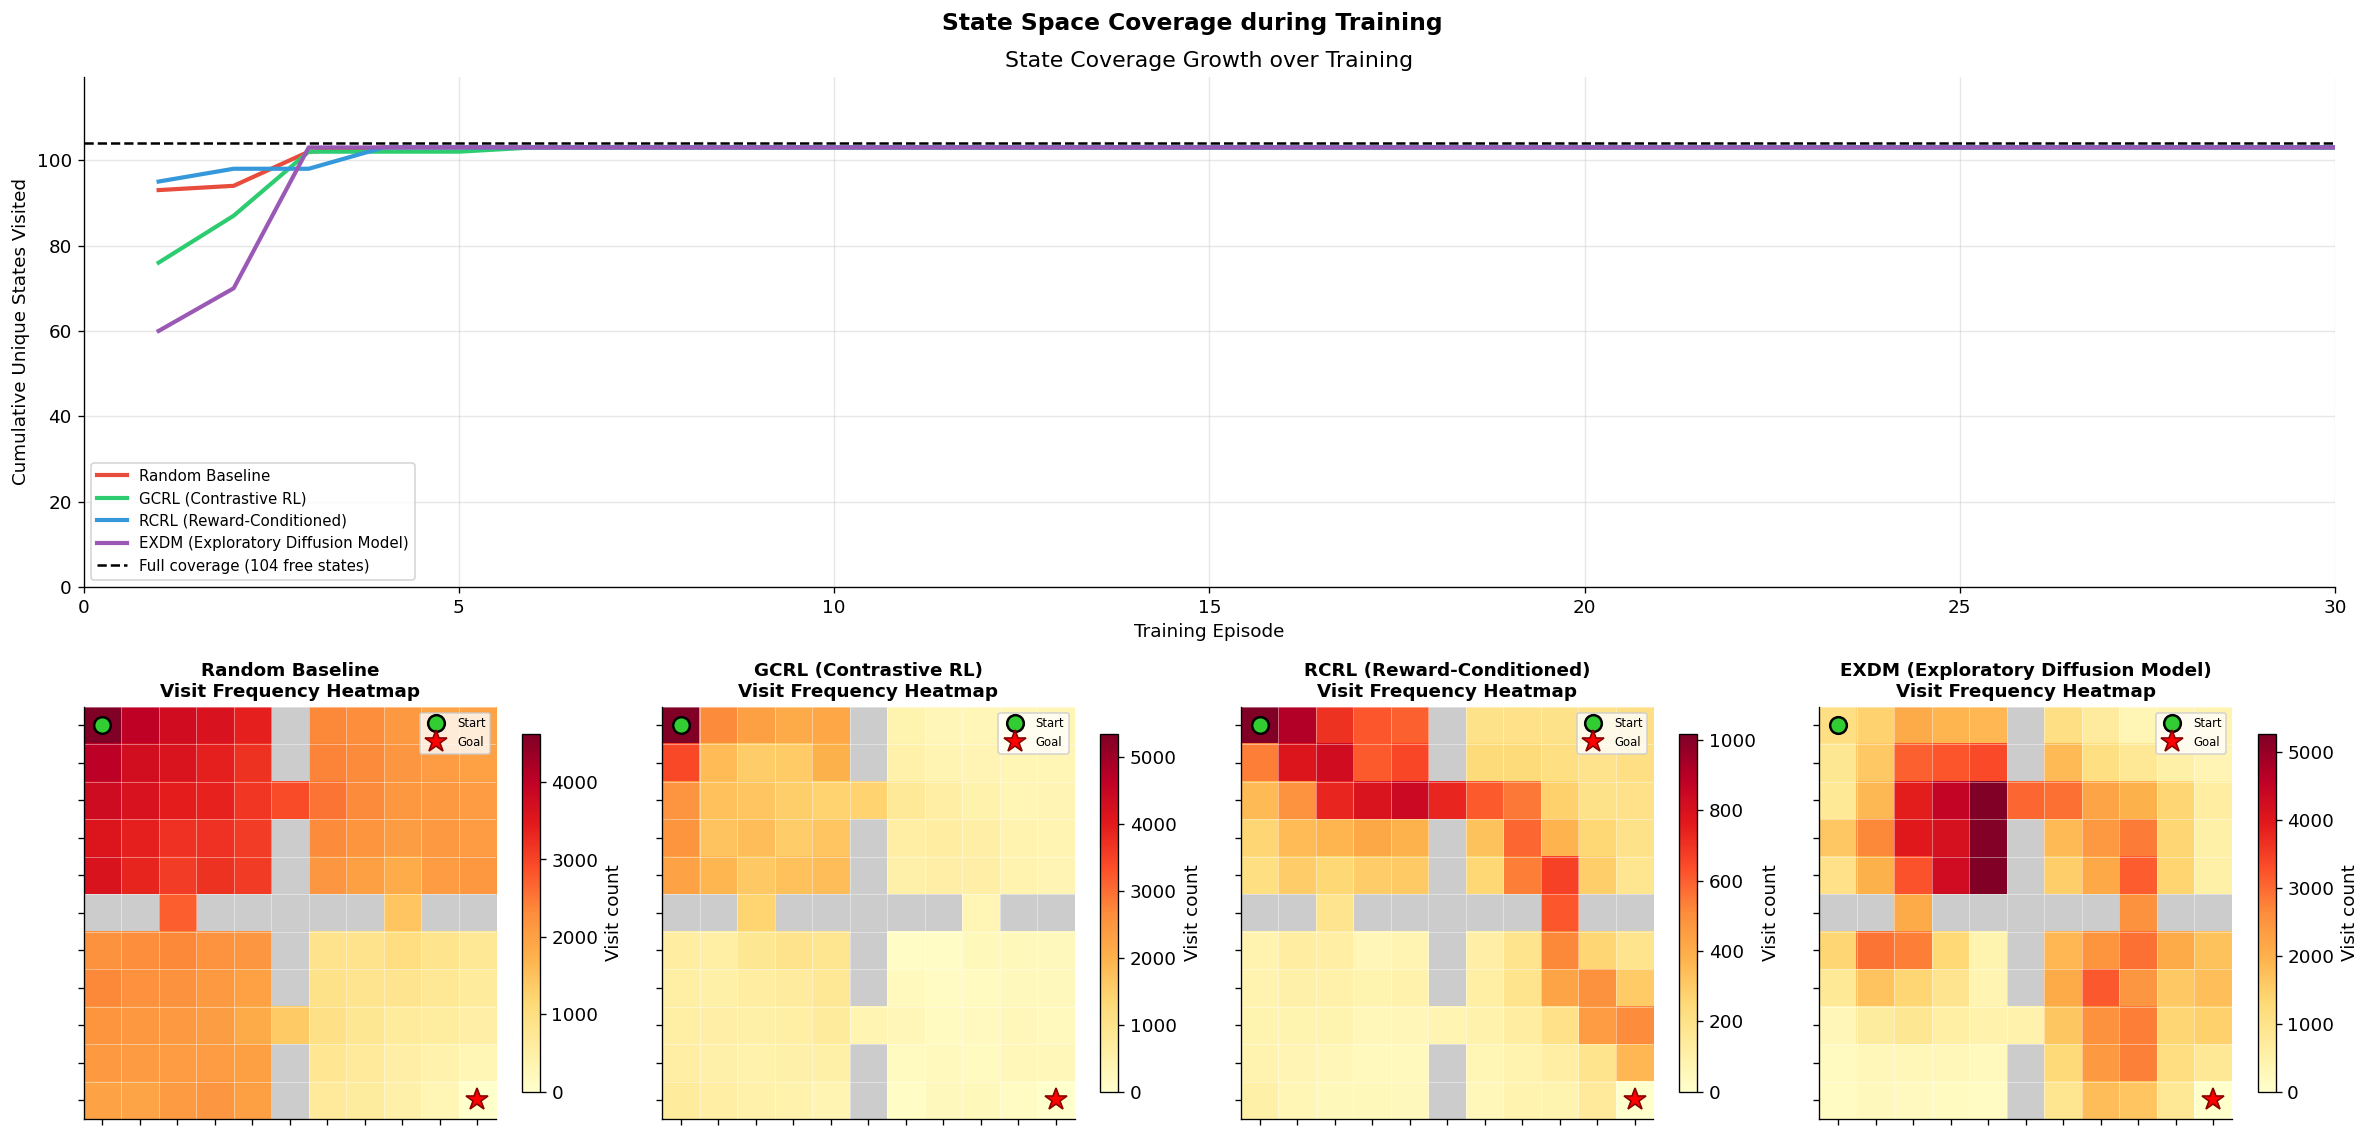

Saved → ../logs/compare/state_coverage.png


In [144]:
# ─────────────────────────────────────────────────────────────────────────────
# State Coverage Analysis — Exploration Performance
# Reads:
#   coverage.csv      — cumulative unique-state counts per episode
#   visit_counts.npy  — per-state visit totals over all training episodes
# Works for any grid environment: open GridWorld, Four-Rooms, Windy GridWorld.
# ─────────────────────────────────────────────────────────────────────────────

TOTAL_STATES = GRID_HEIGHT * GRID_WIDTH

# ─── 1. Load coverage CSVs ────────────────────────────────────────────────────
cov_dfs: dict[str, pd.DataFrame] = {}
for ap in APPROACHES:
    path = LOG_DIR / ap / 'coverage.csv'
    if path.exists():
        cov_dfs[ap] = pd.read_csv(path)
    else:
        print(f'WARNING: {path} not found — run experiments first (Section 1).')

# ─── 2. Load visit-count arrays (one per approach) ───────────────────────────
# visit_counts.npy is a 1-D int32 array of shape (n_states,) saved by
# _compute_and_save_coverage() in compare_approaches.py.
# It accumulates raw step counts across ALL training episodes.
visit_maps: dict[str, np.ndarray] = {}
for ap in APPROACHES:
    path = LOG_DIR / ap / 'visit_counts.npy'
    if path.exists():
        counts = np.load(path).astype(float)
        visit_maps[ap] = counts.reshape(GRID_HEIGHT, GRID_WIDTH)
    else:
        print(f'INFO: visit_counts.npy not found for {ap} — heatmap will be empty.')


free_states = int(TOTAL_STATES - WALL_MASK.sum())

# ─── 4. Quantitative coverage table ──────────────────────────────────────────
if cov_dfs:
    print('STATE COVERAGE SUMMARY')
    print('=' * 80)
    header = (
        f"{'Approach':<35} "
        f"{'States Visited':>15} "
        f"{'Free States':>12} "
        f"{'Coverage (%)':>13}"
    )
    print(header)
    print('-' * 80)
    for ap in APPROACHES:
        if ap not in cov_dfs:
            continue
        df      = cov_dfs[ap]
        visited = int(df.iloc[-1]['unique_states_cumulative'])
        pct     = visited / free_states * 100 if free_states > 0 else 0.0
        print(f"{LABELS[ap]:<35} {visited:>15d} {free_states:>12d} {pct:>12.1f}%")
    print('=' * 80)
    print()

# ─── 5. Visualisation ─────────────────────────────────────────────────────────
# Layout: row 0 = cumulative coverage line chart (full width)
#         row 1 = one visit-frequency heatmap per RL approach
aps_avail = [ap for ap in APPROACHES if ap in cov_dfs]
n_methods = len(aps_avail)

if aps_avail:
    fig = plt.figure(figsize=(max(12, 5 * n_methods), 10))
    ax_line = fig.add_subplot(2, 1, 1)
    ax_heat = [fig.add_subplot(2, n_methods, n_methods + i + 1) for i in range(n_methods)]
    fig.suptitle('State Space Coverage during Training', fontsize=14, fontweight='bold')

    # ── Cumulative coverage line chart ─────────────────────────────────────────
    for ap in aps_avail:
        df = cov_dfs[ap]
        ax_line.plot(
            df['episode'], df['unique_states_cumulative'],
            color=COLORS[ap], linewidth=2.5, label=LABELS[ap],
        )
    ax_line.axhline(
        free_states, color='black', linestyle='--', linewidth=1.5,
        label=f'Full coverage ({free_states} free states)',
    )
    ax_line.set_xlabel('Training Episode')
    ax_line.set_ylabel('Cumulative Unique States Visited')
    ax_line.set_title('State Coverage Growth over Training')
    ax_line.set_ylim(0, free_states * 1.15)
    ax_line.set_xlim(0, N_EPISODES/10)
    ax_line.legend(fontsize=9)
    ax_line.grid(True, alpha=0.3)

    # ── Visit-frequency heatmaps ───────────────────────────────────────────────
    def _plot_visit_heatmap(
        ax, visit_grid: np.ndarray, wall_mask: np.ndarray,
        goal_state: int, start_state: int,
        grid_h: int, grid_w: int, title: str,
    ) -> None:
        """Draw a visit-frequency heatmap on *ax*, masking wall cells in grey.

        Modular helper: works for any GridWorld-derived environment that exposes
        a ``walls`` attribute.  Walls appear as neutral grey cells so the agent's
        actual exploration area is clearly visible.

        Parameters
        ----------
        ax          : matplotlib Axes
        visit_grid  : (H, W) float array of per-cell visit counts
        wall_mask   : (H, W) bool array — True = wall cell
        goal_state  : flat state index of the goal cell
        start_state : flat state index of the start cell
        grid_h, grid_w : grid dimensions
        title       : subplot title text
        """

        display = np.ma.array(visit_grid, mask=wall_mask)
        cmap = plt.cm.YlOrRd.copy()
        cmap.set_bad(color='#cccccc')   # grey for wall cells

        im = ax.imshow(
            display, cmap=cmap, aspect='equal', interpolation='nearest',
            extent=[-0.5, grid_w - 0.5, grid_h - 0.5, -0.5],
            vmin=0,
        )
        plt.colorbar(im, ax=ax, shrink=0.7, label='Visit count')

        # Subtle grid lines
        for x in range(grid_w + 1):
            ax.axvline(x - 0.5, color='white', linewidth=0.4, alpha=0.6)
        for y in range(grid_h + 1):
            ax.axhline(y - 0.5, color='white', linewidth=0.4, alpha=0.6)

        # Start marker (green circle)
        sr, sc = divmod(start_state, grid_w)
        ax.plot(sc, sr, 'o', color='limegreen', markersize=10,
                markeredgecolor='black', markeredgewidth=1.5, zorder=10, label='Start')

        # Goal marker (red star)
        gr, gc = divmod(goal_state, grid_w)
        ax.plot(gc, gr, '*', color='red', markersize=14,
                markeredgecolor='darkred', markeredgewidth=1, zorder=10, label='Goal')

        ax.set_xlim(-0.5, grid_w - 0.5)
        ax.set_ylim(grid_h - 0.5, -0.5)
        ax.set_xticks(range(grid_w))
        ax.set_yticks(range(grid_h))
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=7)

    for ax, ap in zip(ax_heat, aps_avail):
        vmap = visit_maps.get(ap, np.zeros((GRID_HEIGHT, GRID_WIDTH)))
        _plot_visit_heatmap(
            ax, vmap, WALL_MASK,
            goal_state=GOAL_STATE, start_state=START_STATE,
            grid_h=GRID_HEIGHT, grid_w=GRID_WIDTH,
            title=f'{LABELS[ap]}\nVisit Frequency Heatmap',
        )

    plt.tight_layout()
    cov_plot_path = LOG_DIR / 'state_coverage.png'
    plt.savefig(cov_plot_path, bbox_inches='tight', dpi=120)
    plt.show()
    print(f'Saved \u2192 {cov_plot_path}')
else:
    print('No coverage data available. Run Section 1 (FORCE_RERUN=True) first.')


## Path Length to Goal over Training


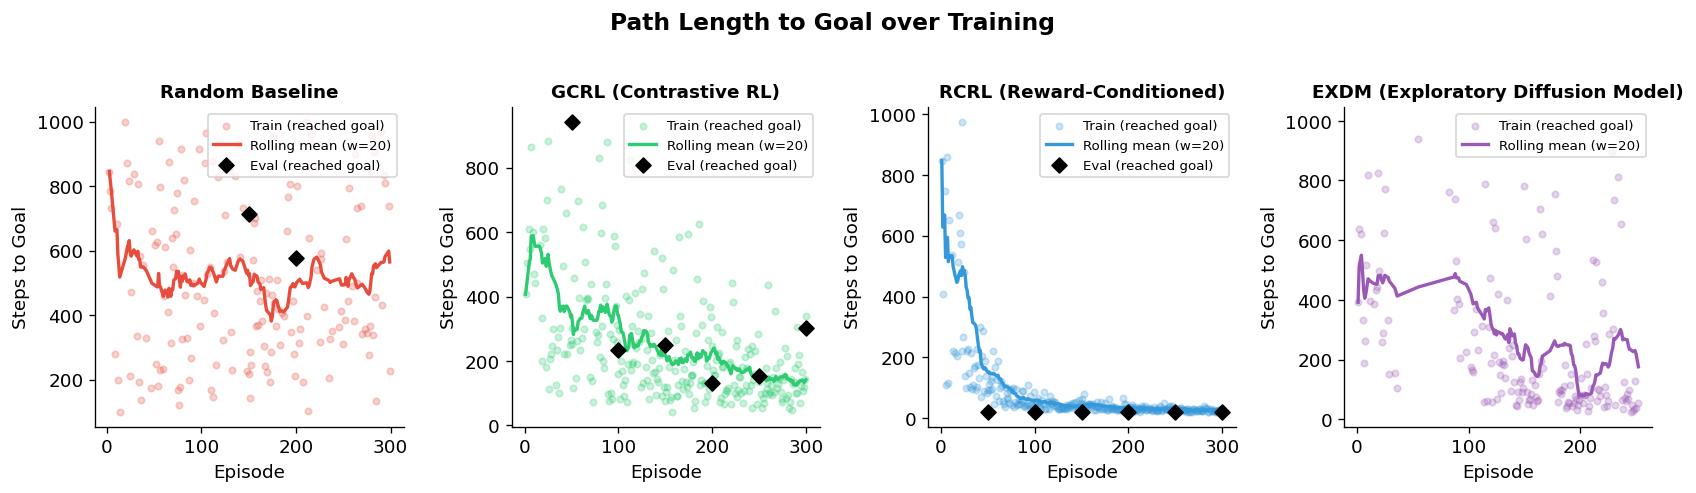

Saved → ../logs/compare/path_length.png


In [145]:
# ─────────────────────────────────────────────────────────────────────────────
# Path Length to Goal over Training
# Shows how the number of steps needed to reach the goal changes across
# training episodes.  Only episodes where the agent reached the goal
# (total_reward > 0) are plotted for training.  Eval episodes are always shown.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, len(APPROACHES), figsize=(14, 4), sharey=False)
fig.suptitle('Path Length to Goal over Training', fontsize=14, fontweight='bold', y=1.02)

for ax, ap in zip(axes, APPROACHES):
    if ap not in dfs:
        ax.set_visible(False)
        continue

    df     = dfs[ap]
    train  = df[(df['mode'] == 'train') & (df['total_reward'] > 0)].reset_index(drop=True)
    evdf   = df[df['mode'] == 'eval'].reset_index(drop=True)

    # Scatter training success episodes
    if len(train) > 0:
        ax.scatter(
            train['episode'], train['length'],
            alpha=0.25, s=15, color=COLORS[ap], label='Train (reached goal)',
        )
        # Rolling mean over success episodes
        mu = train['length'].rolling(min(SMOOTH, len(train)), min_periods=1).mean()
        ax.plot(train['episode'], mu, color=COLORS[ap], linewidth=2,
                label=f'Rolling mean (w={min(SMOOTH, len(train))})')

    # Eval episodes
    if len(evdf) > 0:
        eval_success = evdf[evdf['total_reward'] > 0]
        if len(eval_success) > 0:
            ax.scatter(
                eval_success['episode'], eval_success['length'],
                marker='D', s=40, color='black', zorder=5, label='Eval (reached goal)',
            )

    ax.set_title(LABELS[ap], fontsize=11, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Steps to Goal')
    ax.legend(fontsize=8)

plt.tight_layout()
LOG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(LOG_DIR / 'path_length.png', bbox_inches='tight')
plt.show()
print(f'Saved → {LOG_DIR / "path_length.png"}')


## Q-Value Heatmaps — Training Progression


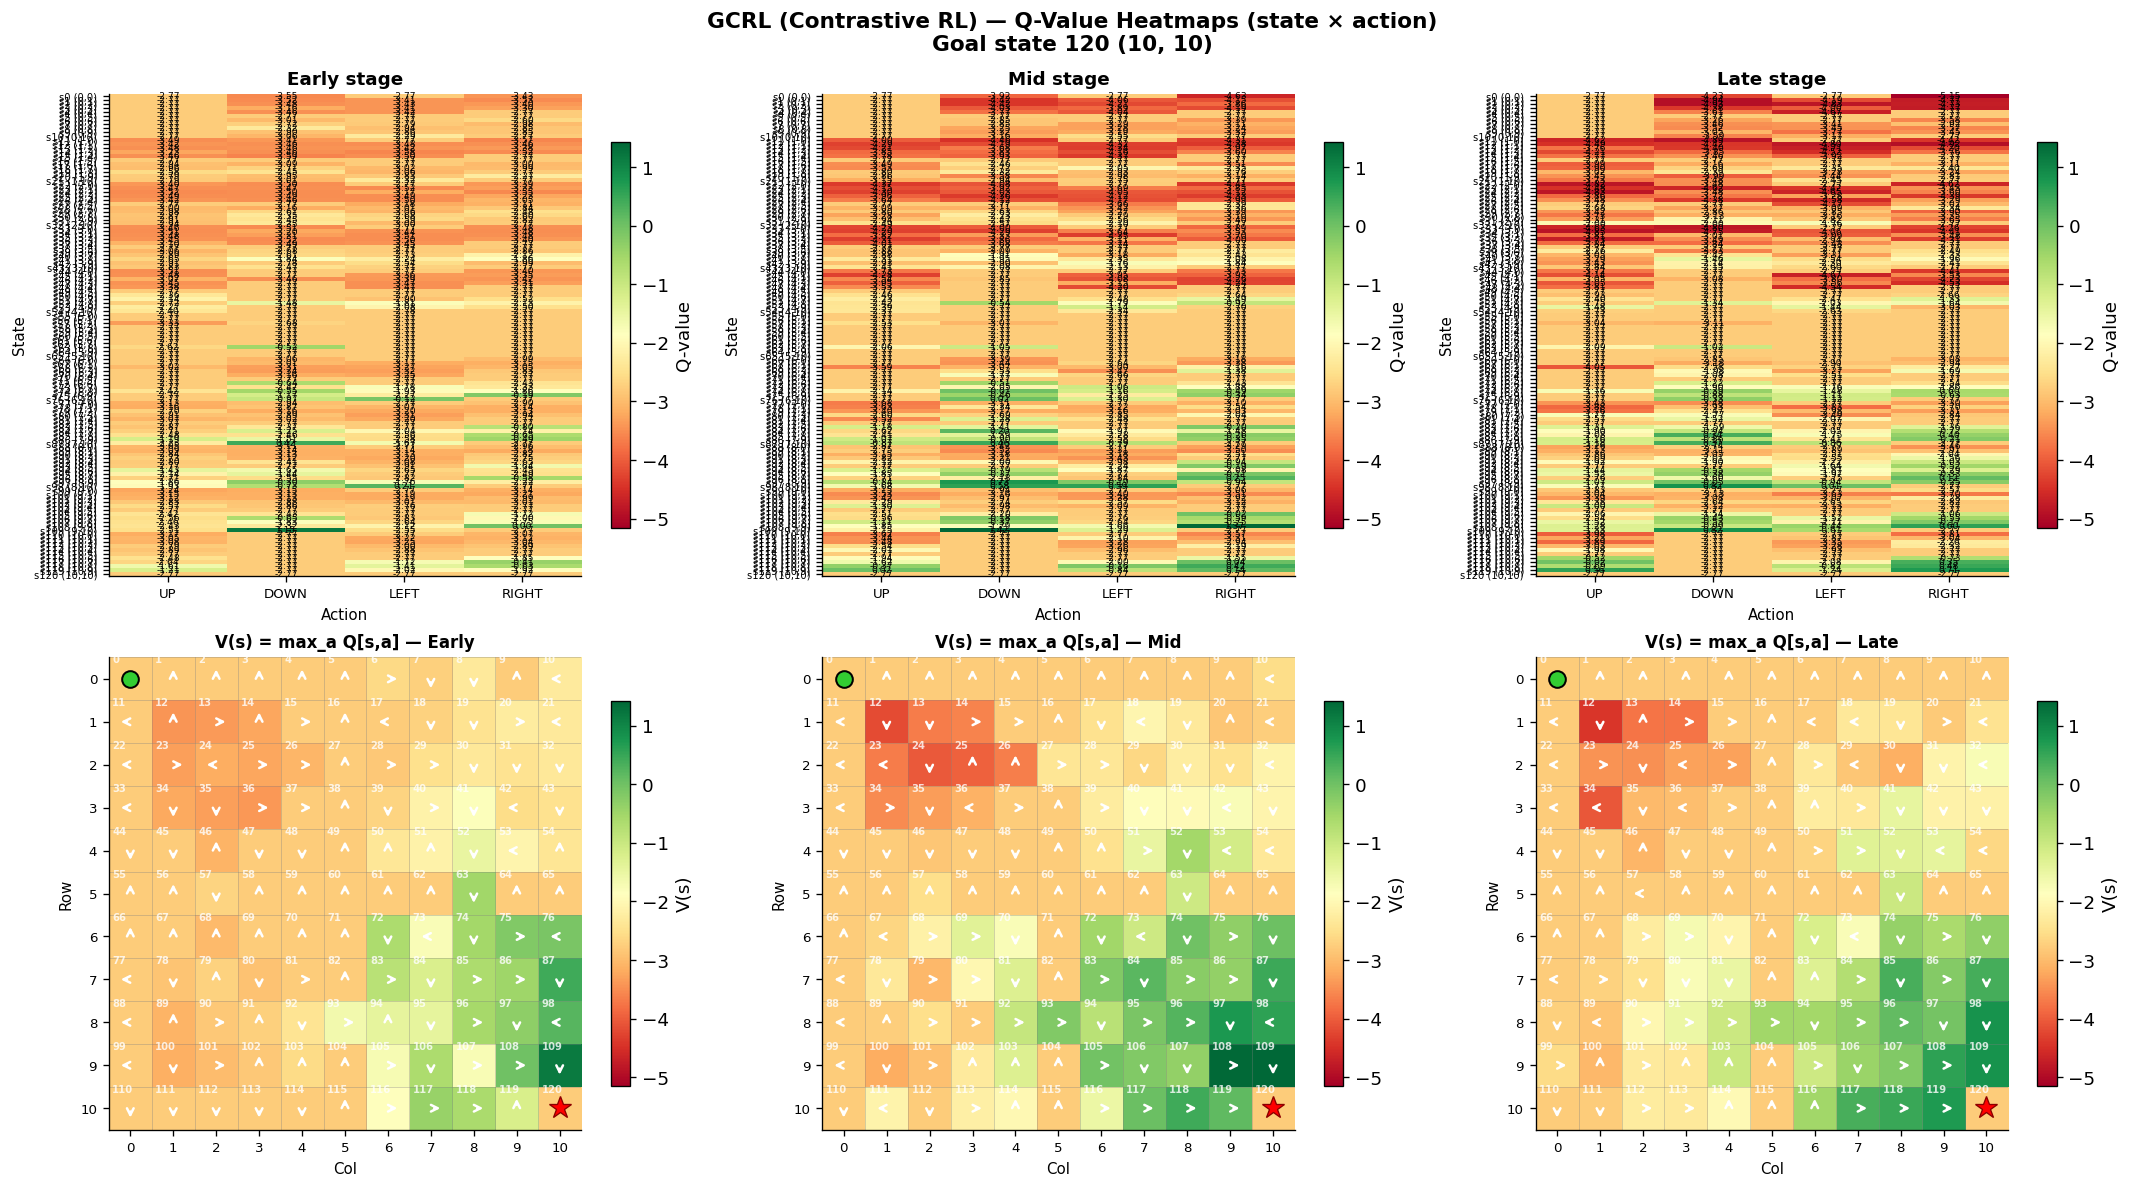

Saved → ../logs/compare/gcrl_q_heatmap.png


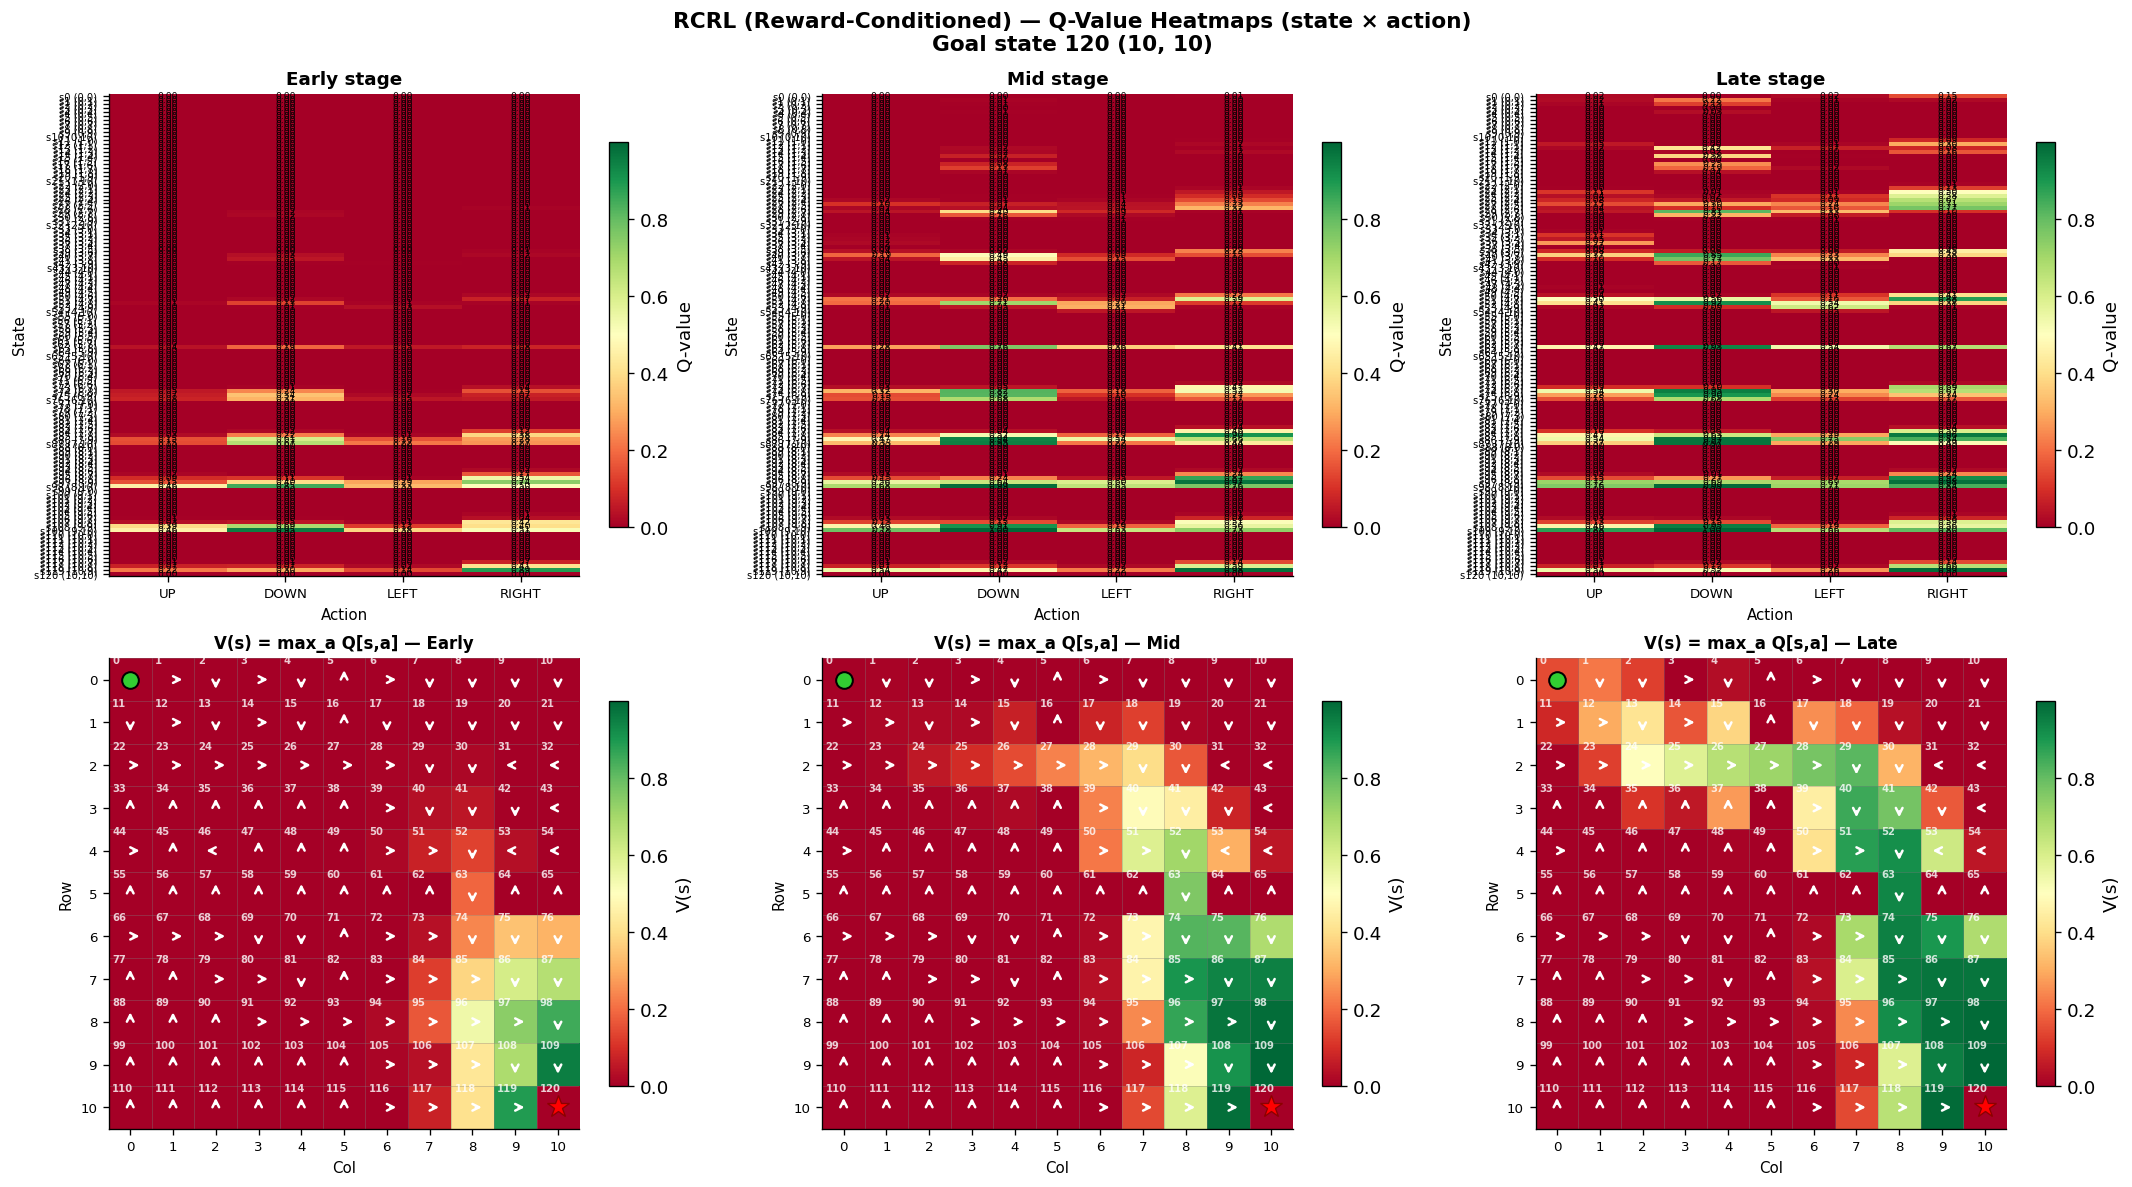

Saved → ../logs/compare/rcrl_q_heatmap.png


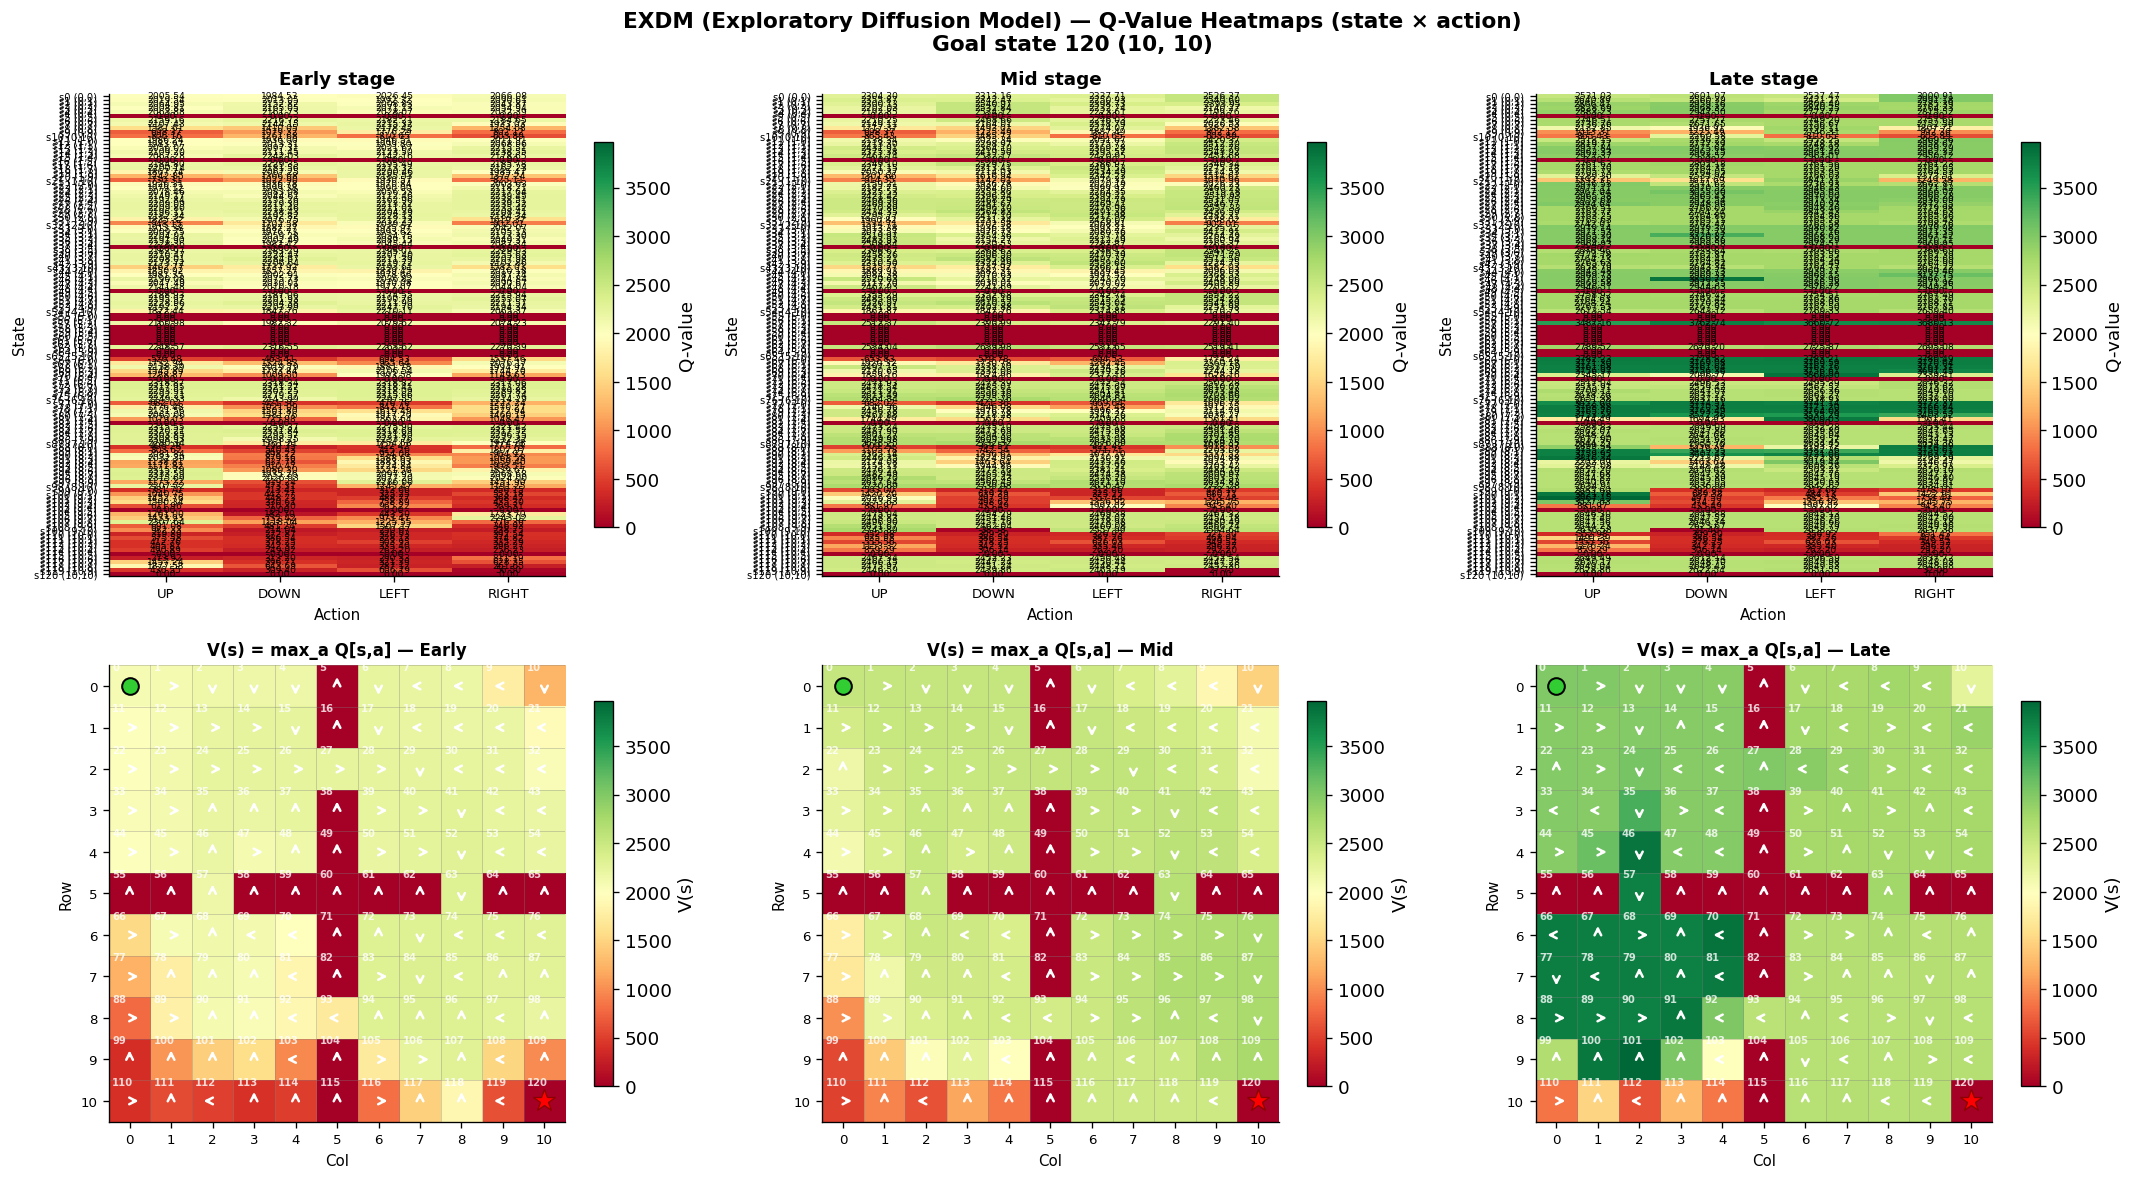

Saved → ../logs/compare/exdm_q_heatmap.png


In [146]:
# ─────────────────────────────────────────────────────────────────────────────
# Q-Value Heatmaps — Early / Mid / Late Training Stages
#
# For RCRL : Q[state, nominal_ψ-bin, action]  →  saved as q_{stage}.npy
# For GCRL : C[state, action, eval_goal]       →  saved as q_{stage}.npy
#
# Each subplot shows:
#   • Left half: state×action Q-value matrix (with labelled axes)
#   • Right half (grid layout): V(s)=max_a Q[s,a] mapped onto the GridWorld,
#     with an arrow overlay showing the greedy action at each state.
# ─────────────────────────────────────────────────────────────────────────────

ACTION_NAMES  = ['UP', 'DOWN', 'LEFT', 'RIGHT']
ACTION_DELTAS = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # (dr, dc) per action
STAGES        = ['early', 'mid', 'late']

# Colour-map shared across stages so comparisons are on the same scale
_CMAP = 'RdYlGn'

for ap in APPROACHES[1:]:
    q_files = [(s, LOG_DIR / ap / f'q_{s}.npy') for s in STAGES]
    available = [(s, f) for s, f in q_files if f.exists()]
    if not available:
        print(f'No Q-snapshots found for {ap} — skipping.')
        continue

    n_stages = len(available)
    # 2 sub-columns per stage: matrix + grid → n_stages * 2 columns total
    fig, axes = plt.subplots(
        2, n_stages,
        figsize=(6 * n_stages, 10),
        gridspec_kw={'height_ratios': [1, 1]},
    )
    if n_stages == 1:
        axes = axes.reshape(2, 1)

    fig.suptitle(
        f'{LABELS[ap]} — Q-Value Heatmaps (state × action)\n'        f'Goal state {GOAL_STATE} ({GOAL_STATE // GRID_WIDTH}, {GOAL_STATE % GRID_WIDTH})',
        fontsize=13, fontweight='bold',
    )

    # Compute global vmin/vmax across all stages for a consistent colour scale
    all_vals = np.concatenate([np.load(f).ravel() for _, f in available])
    vmin, vmax = float(all_vals.min()), float(all_vals.max())
    if vmin == vmax:
        vmin -= 0.01; vmax += 0.01

    for col_idx, (stage, fpath) in enumerate(available):
        Q = np.load(fpath)   # shape: (n_states, n_actions)

        # ── Row 0: state × action heatmap ────────────────────────────────────
        ax_mat = axes[0, col_idx]
        state_labels = [
            f's{i} ({i // GRID_WIDTH},{i % GRID_WIDTH})' for i in range(GRID_HEIGHT * GRID_WIDTH)
        ]
        im = ax_mat.imshow(Q, cmap=_CMAP, aspect='auto', vmin=vmin, vmax=vmax)
        ax_mat.set_xticks(range(4))
        ax_mat.set_xticklabels(ACTION_NAMES, fontsize=8)
        ax_mat.set_yticks(range(GRID_HEIGHT * GRID_WIDTH))
        ax_mat.set_yticklabels(state_labels, fontsize=6)
        ax_mat.set_xlabel('Action', fontsize=9)
        ax_mat.set_ylabel('State', fontsize=9)
        ax_mat.set_title(f'{stage.capitalize()} stage', fontsize=11, fontweight='bold')
        # Annotate each cell with Q-value
        for s in range(GRID_HEIGHT * GRID_WIDTH):
            for a in range(4):
                ax_mat.text(
                    a, s, f'{Q[s, a]:.2f}',
                    ha='center', va='center', fontsize=5.5, color='black',
                )
        plt.colorbar(im, ax=ax_mat, shrink=0.8, label='Q-value')

        # ── Row 1: V(s) = max_a Q[s,a] mapped onto the GridWorld grid ────────
        ax_grid = axes[1, col_idx]
        V = Q.max(axis=1).reshape(GRID_HEIGHT, GRID_WIDTH)
        best_a = Q.argmax(axis=1).reshape(GRID_HEIGHT, GRID_WIDTH)

        im2 = ax_grid.imshow(
            V, cmap=_CMAP, aspect='equal',
            vmin=vmin, vmax=vmax,
            extent=[-0.5, GRID_WIDTH - 0.5, GRID_HEIGHT - 0.5, -0.5],
        )
        # Grid lines
        for x in range(GRID_WIDTH + 1):
            ax_grid.axvline(x - 0.5, color='gray', linewidth=0.5, alpha=0.4)
        for y in range(GRID_HEIGHT + 1):
            ax_grid.axhline(y - 0.5, color='gray', linewidth=0.5, alpha=0.4)

        # Greedy-action arrows and state labels
        for r in range(GRID_HEIGHT):
            for c in range(GRID_WIDTH):
                s_idx = r * GRID_WIDTH + c
                # State index label (top-left corner of cell)
                ax_grid.text(
                    c - 0.42, r - 0.38, str(s_idx),
                    fontsize=6, color='white', fontweight='bold', alpha=0.8,
                )
                # Greedy-action arrow (skip goal state)
                if s_idx == GOAL_STATE:
                    continue
                dr, dc = ACTION_DELTAS[int(best_a[r, c])]
                ax_grid.annotate(
                    '', xy=(c + 0.3 * dc, r + 0.3 * dr), xytext=(c, r),
                    arrowprops=dict(
                        arrowstyle='->', color='white', lw=1.5, mutation_scale=10,
                    ),
                )

        # Start and Goal markers
        sr, sc = divmod(START_STATE, GRID_WIDTH)
        gr, gc = divmod(GOAL_STATE, GRID_WIDTH)
        ax_grid.plot(sc, sr, 'o', color='limegreen', markersize=10,
                     markeredgecolor='black', markeredgewidth=1.2, zorder=10)
        ax_grid.plot(gc, gr, '*', color='red', markersize=14,
                     markeredgecolor='darkred', markeredgewidth=0.8, zorder=10)

        ax_grid.set_xlim(-0.5, GRID_WIDTH - 0.5)
        ax_grid.set_ylim(GRID_HEIGHT - 0.5, -0.5)
        ax_grid.set_xticks(range(GRID_WIDTH))
        ax_grid.set_yticks(range(GRID_HEIGHT))
        ax_grid.set_xticklabels(range(GRID_WIDTH), fontsize=8)
        ax_grid.set_yticklabels(range(GRID_HEIGHT), fontsize=8)
        ax_grid.set_xlabel('Col', fontsize=9)
        ax_grid.set_ylabel('Row', fontsize=9)
        ax_grid.set_title(f'V(s) = max_a Q[s,a] — {stage.capitalize()}',
                          fontsize=10, fontweight='bold')
        plt.colorbar(im2, ax=ax_grid, shrink=0.8, label='V(s)')

    plt.tight_layout()
    out_path = LOG_DIR / f'{ap}_q_heatmap.png'
    plt.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved → {out_path}')


## Section 5 — Transfer Learning: Goal Generalisation

This section evaluates both agents on a **new goal state** that was never
used as the *training* goal.  Two modes are supported:

| Mode | Description |
|------|-------------|
| `zero_shot` | Apply the saved policy directly — no additional training |
| `finetune` | Warm-start from the saved policy, run `N_FINETUNE_EPISODES` on the new goal |
| `both` | Run zero-shot first, then fine-tune, and compare the two |

| Agent | Zero-shot expectation | Fine-tuning expectation |
|-------|-----------------------|-------------------------|
| **RCRL** | Navigates toward *original* goal → 0 reward on new goal | Q-table quickly re-pointed at new goal via warm-start Q-learning |
| **GCRL** | C[s,:,new_goal] may already generalise if new_goal was a training future state | Fast convergence from warm-started C-table |

> **Key insight** (Liu et al., 2024): Although GCRL conditions data collection
> on a *single* hard goal, the contrastive objective implicitly trains
> ``C[s, a, sf]`` for every future state ``sf`` visited during training,
> creating a multi-goal value function at no extra cost.  Fine-tuning
> reinforces the signal for the specific new goal.


In [151]:
# ─────────────────────────────────────────────────────────────────────────────
# Transfer-goal configuration
# ─────────────────────────────────────────────────────────────────────────────

# New goal: choose any state != GOAL_STATE.
# State 9 = top-right corner (0,9) on a 10×10 grid — the opposite direction
# of the default training goal (9,9), making transfer harder for RCRL.
TRANSFER_GOAL_STATE = 10                     # flat index; change to explore
TRANSFER_GOAL_ROW, TRANSFER_GOAL_COL = divmod(TRANSFER_GOAL_STATE, GRID_WIDTH)

# Transfer mode: 'zero_shot', 'finetune', or 'both'
#   zero_shot  — evaluate the saved policy directly on the new goal (no extra training)
#   finetune   — warm-start from the saved policy and run N_FINETUNE_EPISODES
#   both       — run zero-shot first, then fine-tune, and compare
TRANSFER_MODE = 'finetune'                       # change to 'zero_shot' or 'finetune'

# Fine-tuning hyperparameters (ignored in zero_shot mode)
N_FINETUNE_EPISODES  = 50    # short burst of goal-specific training
FINETUNE_ALPHA       = 0.1   # learning rate for fine-tuning
FINETUNE_EPSILON     = 0.2   # initial epsilon for RCRL fine-tuning (lower = exploit more)

# Number of evaluation episodes to average over
N_TRANSFER_EPISODES = 30

print(f'Transfer goal : state {TRANSFER_GOAL_STATE} '
      f'= row {TRANSFER_GOAL_ROW}, col {TRANSFER_GOAL_COL}')
print(f'Original goal : state {GOAL_STATE} '
      f'= row {GOAL_STATE // GRID_WIDTH}, col {GOAL_STATE % GRID_WIDTH}')
print(f'Transfer mode : {TRANSFER_MODE}')
if TRANSFER_MODE != 'zero_shot':
    print(f'Fine-tune eps : {N_FINETUNE_EPISODES}')


Transfer goal : state 10 = row 0, col 10
Original goal : state 120 = row 10, col 10
Transfer mode : finetune
Fine-tune eps : 50


In [152]:
# ─────────────────────────────────────────────────────────────────────────────
# Load saved Q / C tables
# ─────────────────────────────────────────────────────────────────────────────
from utils.transfer_eval import (
    run_greedy_episode,
    rcrl_action_fn, gcrl_action_fn, exdm_action_fn,
    rcrl_finetune, gcrl_finetune, exdm_finetune,
    TransferResult,
)
from environments.gridworld import GridWorld

# q_late.npy = nominal Q-slice Q[:, psi*, :] (shape: n_states x n_actions)
# q_table.npy = full Q-table (shape: n_states x n_psi_bins x n_actions) — needed for fine-tuning
_rcrl_q_late_path  = LOG_DIR / 'rcrl' / 'q_late.npy'
_rcrl_q_table_path = LOG_DIR / 'rcrl' / 'q_table.npy'
_gcrl_c_table_path = LOG_DIR / 'gcrl' / 'c_table.npy'
_exdm_q_table_path = LOG_DIR / 'exdm' / 'q_table.npy'

for _p in [_rcrl_q_late_path, _gcrl_c_table_path]:
    if not _p.exists():
        raise FileNotFoundError(
            f'Required artefact not found: {_p}\n'
            'Re-run Section 1 with FORCE_RERUN=True to regenerate it.'
        )

rcrl_q_late = np.load(_rcrl_q_late_path)   # shape: (n_states, n_actions) — nominal psi* slice
gcrl_c      = np.load(_gcrl_c_table_path)  # shape: (n_states, n_actions, n_states)

# Full Q-table for fine-tuning (may not exist if run_rcrl was run with an older version)
rcrl_q_full = None
if _rcrl_q_table_path.exists():
    rcrl_q_full = np.load(_rcrl_q_table_path)  # shape: (n_states, n_psi_bins, n_actions)
elif TRANSFER_MODE != 'zero_shot':
    print('WARNING: q_table.npy not found — RCRL fine-tuning will use a nominal-slice warm start.')

# ExDM Q-table for zero-shot and fine-tuning
exdm_q = None
if _exdm_q_table_path.exists():
    exdm_q = np.load(_exdm_q_table_path)   # shape: (n_states, n_actions)
    print(f'ExDM Q-table:                {exdm_q.shape}')
else:
    print('WARNING: ExDM q_table.npy not found — re-run Section 1 with FORCE_RERUN=True.')

print(f'RCRL Q-slice (nominal psi*): {rcrl_q_late.shape}')
if rcrl_q_full is not None:
    print(f'RCRL Q-table (full):         {rcrl_q_full.shape}')
print(f'GCRL C-table (full):         {gcrl_c.shape}')


ExDM Q-table:                (121, 4)
RCRL Q-slice (nominal psi*): (121, 4)
RCRL Q-table (full):         (121, 5, 4)
GCRL C-table (full):         (121, 4, 121)


In [153]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper: build the transfer-goal environment
# ─────────────────────────────────────────────────────────────────────────────
def _new_goal_env():
    """Create an environment whose terminal state is the transfer goal."""
    return GridWorld(
        height=GRID_HEIGHT, width=GRID_WIDTH,
        start_pos=(START_STATE // GRID_WIDTH, START_STATE % GRID_WIDTH),
        goal_pos=(TRANSFER_GOAL_ROW, TRANSFER_GOAL_COL),
        max_steps=MAX_STEPS,
    )

def _run_episodes(action_fn, n=N_TRANSFER_EPISODES, base_seed=SEED + 100):
    """Run N evaluation episodes and return a list of TransferResult."""
    rng = np.random.default_rng(base_seed)
    results = []
    for _ in range(n):
        seed = int(rng.integers(0, 2**31))
        results.append(run_greedy_episode(_new_goal_env(), action_fn, seed=seed))
    return results

def _summary(results, label):
    rewards   = [r.total_reward for r in results]
    lengths   = [r.length       for r in results]
    successes = [r.reached_goal for r in results]
    print(f'  {label:<45s}  '
          f'mean_reward={np.mean(rewards):.3f}  '
          f'success_rate={np.mean(successes)*100:.0f}%  '
          f'mean_length={np.mean(lengths):.1f}')
    return dict(rewards=rewards, successes=successes, lengths=lengths)

# ─────────────────────────────────────────────────────────────────────────────
# Zero-shot evaluation
# ─────────────────────────────────────────────────────────────────────────────
rcrl_zs_results = gcrl_zs_results = exdm_zs_results = None

if TRANSFER_MODE in ('zero_shot', 'both'):
    print(f'\n── Zero-shot: original goal {GOAL_STATE} → new goal {TRANSFER_GOAL_STATE} ──')
    rcrl_fn_zs = rcrl_action_fn(rcrl_q_late)
    gcrl_fn_zs = gcrl_action_fn(gcrl_c, TRANSFER_GOAL_STATE)
    rcrl_zs_results = _run_episodes(rcrl_fn_zs)
    gcrl_zs_results = _run_episodes(gcrl_fn_zs)
    rcrl_zs_stats = _summary(rcrl_zs_results, 'RCRL  zero-shot')
    gcrl_zs_stats = _summary(gcrl_zs_results, 'GCRL  zero-shot')
    if exdm_q is not None:
        exdm_fn_zs = exdm_action_fn(exdm_q)
        exdm_zs_results = _run_episodes(exdm_fn_zs)
        exdm_zs_stats = _summary(exdm_zs_results, 'ExDM  zero-shot')

# ─────────────────────────────────────────────────────────────────────────────
# Fine-tuning + evaluation
# ─────────────────────────────────────────────────────────────────────────────
rcrl_ft_results = gcrl_ft_results = exdm_ft_results = None
rcrl_q_finetuned = gcrl_c_finetuned = exdm_q_finetuned = None

if TRANSFER_MODE in ('finetune', 'both'):
    print(f'\n── Fine-tuning ({N_FINETUNE_EPISODES} eps): original goal {GOAL_STATE} → new goal {TRANSFER_GOAL_STATE} ──')

    # RCRL fine-tuning — use full Q-table if available, else build from nominal slice
    _n_psi_bins = rcrl_q_full.shape[1] if rcrl_q_full is not None else 5
    _q_for_ft   = rcrl_q_full if rcrl_q_full is not None else None
    if _q_for_ft is None:
        # Fallback: construct a 3-D Q-table with 1 psi bin from the late slice
        _q_for_ft = rcrl_q_late[:, np.newaxis, :]  # (n_states, 1, n_actions)
        _n_psi_bins = 1

    print('  Fine-tuning RCRL...')
    _min_path = (GRID_HEIGHT - 1) + (GRID_WIDTH - 1)
    rcrl_fn_ft, rcrl_q_finetuned = rcrl_finetune(
        _q_for_ft,
        _new_goal_env(),
        nominal_psi_bin=0,
        n_episodes=N_FINETUNE_EPISODES,
        alpha=FINETUNE_ALPHA,
        epsilon=FINETUNE_EPSILON,
        seed=SEED + 200,
    )

    print('  Fine-tuning GCRL...')
    _cg = _min_path / (_min_path + 1)
    gcrl_fn_ft, gcrl_c_finetuned = gcrl_finetune(
        gcrl_c,
        TRANSFER_GOAL_STATE,
        _new_goal_env(),
        n_episodes=N_FINETUNE_EPISODES,
        alpha=FINETUNE_ALPHA,
        contrastive_gamma=_cg,
        seed=SEED + 300,
    )

    if exdm_q is not None:
        print('  Fine-tuning ExDM...')
        exdm_fn_ft, exdm_q_finetuned = exdm_finetune(
            exdm_q,
            _new_goal_env(),
            n_episodes=N_FINETUNE_EPISODES,
            alpha=FINETUNE_ALPHA,
            epsilon=FINETUNE_EPSILON,
            seed=SEED + 350,
        )

    rcrl_ft_results = _run_episodes(rcrl_fn_ft, base_seed=SEED + 400)
    gcrl_ft_results = _run_episodes(gcrl_fn_ft, base_seed=SEED + 400)
    rcrl_ft_stats = _summary(rcrl_ft_results, f'RCRL  fine-tuned ({N_FINETUNE_EPISODES} eps)')
    gcrl_ft_stats = _summary(gcrl_ft_results, f'GCRL  fine-tuned ({N_FINETUNE_EPISODES} eps)')
    if exdm_ft_results is None and exdm_q is not None:
        exdm_ft_results = _run_episodes(exdm_fn_ft, base_seed=SEED + 400)
        exdm_ft_stats = _summary(exdm_ft_results, f'ExDM  fine-tuned ({N_FINETUNE_EPISODES} eps)')

# ─────────────────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────────────────
if TRANSFER_MODE == 'both':
    _rows = [('RCRL', rcrl_zs_stats, rcrl_ft_stats),
             ('GCRL', gcrl_zs_stats, gcrl_ft_stats)]
    if exdm_q is not None:
        _rows.append(('ExDM', exdm_zs_stats, exdm_ft_stats))
    print('\n╔══════════════════════════════════════════════════════════════╗')
    print(  '║  Transfer Learning Summary (goal {} → {})                     ║'.format(GOAL_STATE, TRANSFER_GOAL_STATE))
    print(  '╠════════════════╦═══════════════╦═══════════════════════════════╣')
    print(  '║ Agent          ║   Zero-shot   ║      Fine-tuned               ║')
    print(  '╠════════════════╬═══════════════╬═══════════════════════════════╣')
    for label, zs, ft in _rows:
        zs_sr = f'{np.mean(zs["successes"])*100:.0f}%'
        ft_sr = f'{np.mean(ft["successes"])*100:.0f}%'
        print(f'║ {label:<14s} ║ {zs_sr:>13s} ║ {ft_sr:>29s} ║')
    print(  '╚════════════════╩═══════════════╩═══════════════════════════════╝')



── Fine-tuning (50 eps): original goal 120 → new goal 10 ──
  Fine-tuning RCRL...
  Fine-tuning GCRL...
  Fine-tuning ExDM...
  RCRL  fine-tuned (50 eps)                      mean_reward=0.000  success_rate=0%  mean_length=1000.0
  GCRL  fine-tuned (50 eps)                      mean_reward=0.000  success_rate=0%  mean_length=1000.0
  ExDM  fine-tuned (50 eps)                      mean_reward=0.000  success_rate=0%  mean_length=1000.0


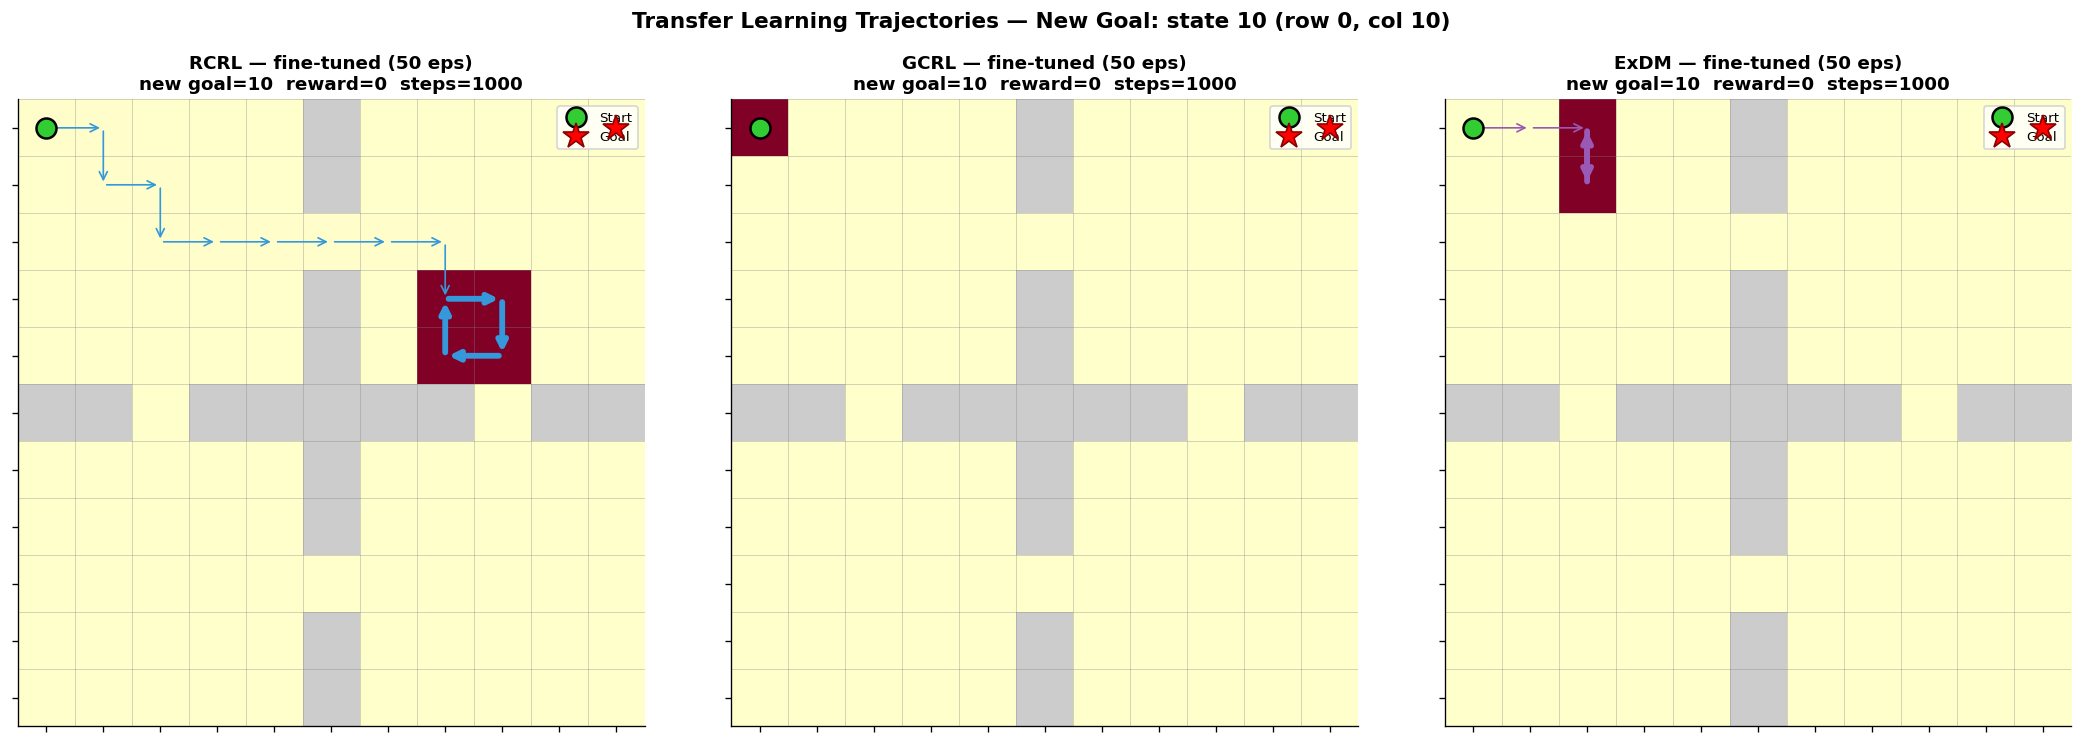

Saved -> ../logs/compare/transfer_trajectory.png


In [154]:
# ─────────────────────────────────────────────────────────────────────────────
# Trajectory visualisation — RCRL vs GCRL vs ExDM on the new goal
# Shows zero-shot and/or fine-tuned trajectories depending on TRANSFER_MODE.
# ─────────────────────────────────────────────────────────────────────────────
def _best_or_last(results):
    """Return the first successful episode, or the last episode if none succeeded."""
    successes = [r for r in results if r.reached_goal]
    return successes[0] if successes else results[-1]

def _to_df(tr: TransferResult):
    return pd.DataFrame(tr.trajectory, columns=['step', 'state', 'action', 'reward'])

# Collect panels to show
_panels = []  # (result, label, color)
if rcrl_zs_results is not None:
    _panels.append((_best_or_last(rcrl_zs_results), 'RCRL — zero-shot',         COLORS['rcrl']))
if gcrl_zs_results is not None:
    _panels.append((_best_or_last(gcrl_zs_results), 'GCRL — zero-shot',         COLORS['gcrl']))
if exdm_zs_results is not None:
    _panels.append((_best_or_last(exdm_zs_results), 'ExDM — zero-shot',         COLORS['exdm']))
if rcrl_ft_results is not None:
    _panels.append((_best_or_last(rcrl_ft_results), f'RCRL — fine-tuned ({N_FINETUNE_EPISODES} eps)', COLORS['rcrl']))
if gcrl_ft_results is not None:
    _panels.append((_best_or_last(gcrl_ft_results), f'GCRL — fine-tuned ({N_FINETUNE_EPISODES} eps)', COLORS['gcrl']))
if exdm_ft_results is not None:
    _panels.append((_best_or_last(exdm_ft_results), f'ExDM — fine-tuned ({N_FINETUNE_EPISODES} eps)', COLORS['exdm']))

n_panels = len(_panels)
if n_panels == 0:
    print('No transfer results to visualise.')
else:
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))
    if n_panels == 1:
        axes = [axes]

    for ax, (tr, label, color) in zip(axes, _panels):
        df = _to_df(tr)
        plot_trajectory(
            ax, df,
            grid_height=GRID_HEIGHT, grid_width=GRID_WIDTH,
            goal_state=TRANSFER_GOAL_STATE, start_state=START_STATE,
            title=(
                f'{label}\n'
                f'new goal={TRANSFER_GOAL_STATE}  '
                f'reward={tr.total_reward:.0f}  steps={tr.length}'
            ),
            color=color,
            walls=WALL_MASK,
        )

    plt.suptitle(
        f'Transfer Learning Trajectories — New Goal: state {TRANSFER_GOAL_STATE} '
        f'(row {TRANSFER_GOAL_ROW}, col {TRANSFER_GOAL_COL})',
        fontsize=13, fontweight='bold', y=1.02,
    )
    plt.tight_layout()
    _traj_path = LOG_DIR / 'transfer_trajectory.png'
    plt.savefig(_traj_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {_traj_path}')


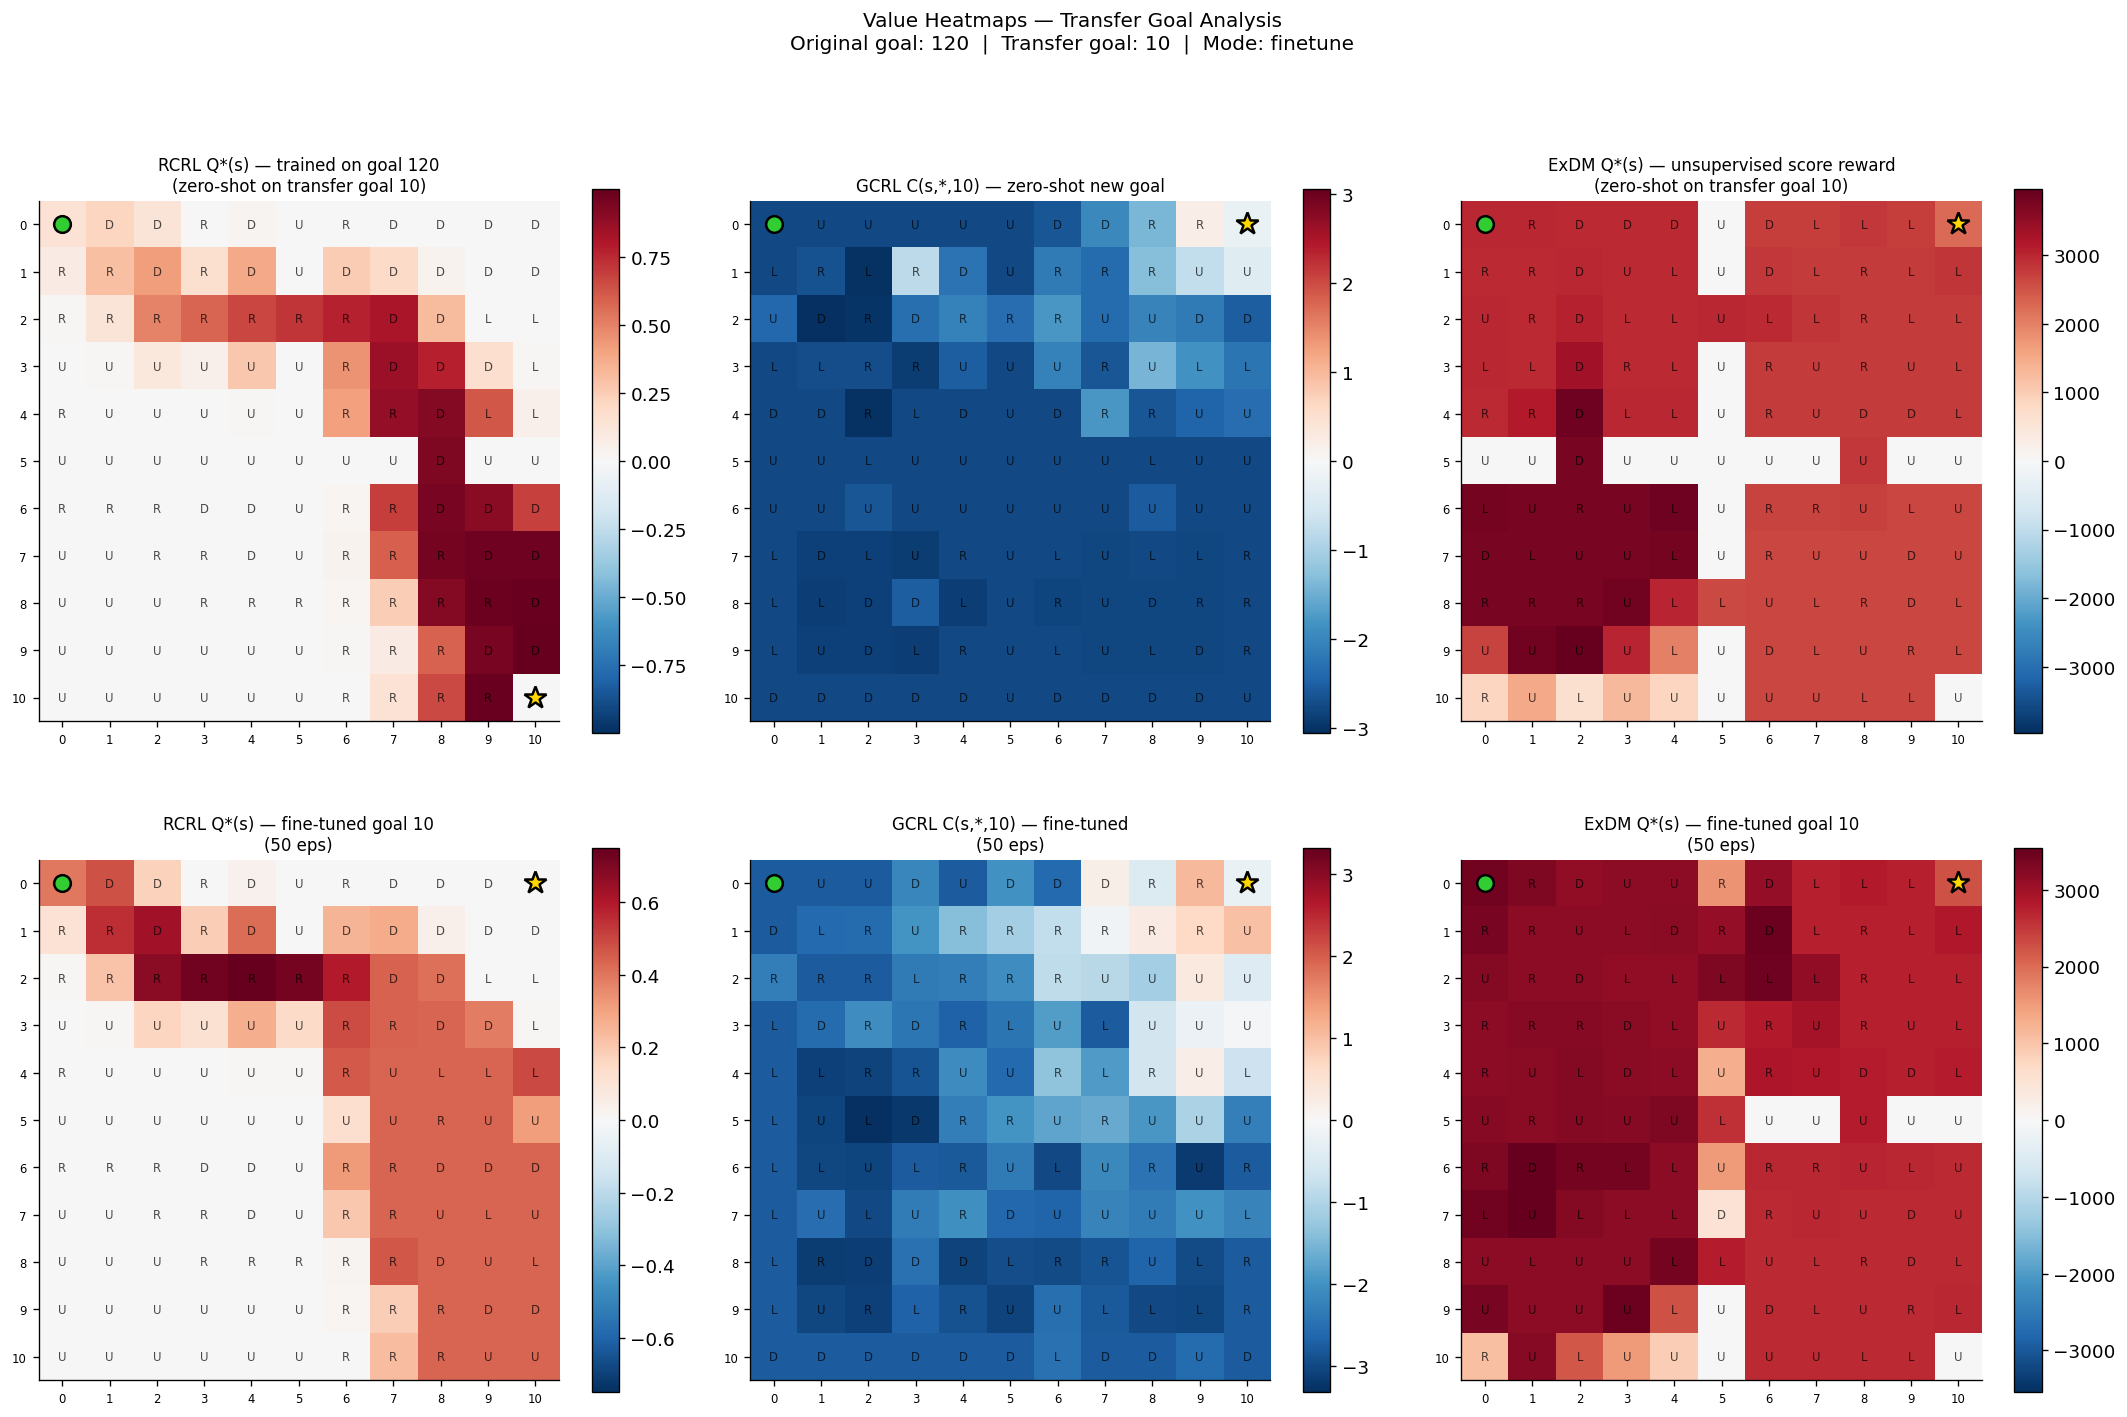

Saved -> ../logs/compare/transfer_heatmap.png


In [155]:
# ─────────────────────────────────────────────────────────────────────────────
# Q/C Value Heatmaps — Transfer Goal
#
# Row 0 — Zero-shot:
#   RCRL  Q*(s) trained for ORIGINAL goal  (still pointing at original goal)
#   GCRL  C(s,*,transfer_goal)             (zero-shot new goal)
#   ExDM  Q*(s) trained via score-reward   (unsupervised — no goal bias)
#
# Row 1 (if fine-tuned) — After fine-tuning:
#   RCRL  Q*(s) fine-tuned for new goal
#   GCRL  C(s,*,transfer_goal) fine-tuned for new goal
#   ExDM  Q*(s) fine-tuned for new goal
# ─────────────────────────────────────────────────────────────────────────────
ACTION_SYMBOLS = {0: 'U', 1: 'D', 2: 'L', 3: 'R'}
_cmap_div = plt.cm.RdBu_r

def _plot_value_heatmap(ax, values_flat, best_actions, grid_h, grid_w,
                         title, goal_state, start_state, cmap):
    V = values_flat.reshape(grid_h, grid_w)
    vmax = np.abs(V).max() or 1.0
    im = ax.imshow(V, cmap=cmap, aspect='equal', vmin=-vmax, vmax=vmax,
                   extent=[-0.5, grid_w - 0.5, grid_h - 0.5, -0.5])
    plt.colorbar(im, ax=ax, shrink=0.8)
    for s in range(grid_h * grid_w):
        r, c = divmod(s, grid_w)
        ax.text(c, r, ACTION_SYMBOLS.get(best_actions[s], '?'),
                ha='center', va='center', fontsize=7, color='black', alpha=0.7)
    sr, sc = divmod(start_state, grid_w)
    gr, gc = divmod(goal_state, grid_w)
    ax.plot(sc, sr, 'o', color='limegreen', markersize=10,
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    ax.plot(gc, gr, '*', color='gold', markersize=14,
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(grid_w)); ax.set_yticks(range(grid_h))
    ax.set_xticklabels(range(grid_w), fontsize=7)
    ax.set_yticklabels(range(grid_h), fontsize=7)

# ── Zero-shot values ──────────────────────────────────────────────────────
rcrl_vals_zs = rcrl_q_late.max(axis=1)
rcrl_best_zs = rcrl_q_late.argmax(axis=1)

gcrl_vals_tg_zs   = gcrl_c[:, :, TRANSFER_GOAL_STATE].max(axis=1)
gcrl_best_a_tg_zs = gcrl_c[:, :, TRANSFER_GOAL_STATE].argmax(axis=1)

_has_exdm    = exdm_q is not None
_has_ft      = rcrl_q_finetuned is not None or gcrl_c_finetuned is not None or exdm_q_finetuned is not None
n_rows = 1 + (1 if _has_ft else 0)
n_cols = 3  # RCRL | GCRL | ExDM

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]

# Row 0: zero-shot
_plot_value_heatmap(
    axes[0, 0], rcrl_vals_zs, rcrl_best_zs, GRID_HEIGHT, GRID_WIDTH,
    title=f'RCRL Q*(s) — trained on goal {GOAL_STATE}\n(zero-shot on transfer goal {TRANSFER_GOAL_STATE})',
    goal_state=GOAL_STATE, start_state=START_STATE, cmap=_cmap_div,
)
_plot_value_heatmap(
    axes[0, 1], gcrl_vals_tg_zs, gcrl_best_a_tg_zs, GRID_HEIGHT, GRID_WIDTH,
    title=f'GCRL C(s,*,{TRANSFER_GOAL_STATE}) — zero-shot new goal',
    goal_state=TRANSFER_GOAL_STATE, start_state=START_STATE, cmap=_cmap_div,
)
if _has_exdm:
    exdm_vals_zs = exdm_q.max(axis=1)
    exdm_best_zs = exdm_q.argmax(axis=1)
    _plot_value_heatmap(
        axes[0, 2], exdm_vals_zs, exdm_best_zs, GRID_HEIGHT, GRID_WIDTH,
        title=f'ExDM Q*(s) — unsupervised score reward\n(zero-shot on transfer goal {TRANSFER_GOAL_STATE})',
        goal_state=TRANSFER_GOAL_STATE, start_state=START_STATE, cmap=_cmap_div,
    )
else:
    axes[0, 2].set_visible(False)

# Row 1: fine-tuned (if available)
if n_rows > 1:
    if rcrl_q_finetuned is not None:
        _rcrl_ft_nominal = rcrl_q_finetuned[:, 0, :] if rcrl_q_finetuned.ndim == 3 else rcrl_q_finetuned
        _plot_value_heatmap(
            axes[1, 0], _rcrl_ft_nominal.max(axis=1), _rcrl_ft_nominal.argmax(axis=1),
            GRID_HEIGHT, GRID_WIDTH,
            title=f'RCRL Q*(s) — fine-tuned goal {TRANSFER_GOAL_STATE}\n({N_FINETUNE_EPISODES} eps)',
            goal_state=TRANSFER_GOAL_STATE, start_state=START_STATE, cmap=_cmap_div,
        )
    else:
        axes[1, 0].set_visible(False)

    if gcrl_c_finetuned is not None:
        gcrl_vals_ft   = gcrl_c_finetuned[:, :, TRANSFER_GOAL_STATE].max(axis=1)
        gcrl_best_a_ft = gcrl_c_finetuned[:, :, TRANSFER_GOAL_STATE].argmax(axis=1)
        _plot_value_heatmap(
            axes[1, 1], gcrl_vals_ft, gcrl_best_a_ft, GRID_HEIGHT, GRID_WIDTH,
            title=f'GCRL C(s,*,{TRANSFER_GOAL_STATE}) — fine-tuned\n({N_FINETUNE_EPISODES} eps)',
            goal_state=TRANSFER_GOAL_STATE, start_state=START_STATE, cmap=_cmap_div,
        )
    else:
        axes[1, 1].set_visible(False)

    if exdm_q_finetuned is not None:
        _plot_value_heatmap(
            axes[1, 2], exdm_q_finetuned.max(axis=1), exdm_q_finetuned.argmax(axis=1),
            GRID_HEIGHT, GRID_WIDTH,
            title=f'ExDM Q*(s) — fine-tuned goal {TRANSFER_GOAL_STATE}\n({N_FINETUNE_EPISODES} eps)',
            goal_state=TRANSFER_GOAL_STATE, start_state=START_STATE, cmap=_cmap_div,
        )
    else:
        axes[1, 2].set_visible(False)

plt.suptitle(
    'Value Heatmaps — Transfer Goal Analysis\n'
    f'Original goal: {GOAL_STATE}  |  Transfer goal: {TRANSFER_GOAL_STATE}  |  Mode: {TRANSFER_MODE}',
    fontsize=12, y=1.02,
)
plt.tight_layout()
_heatmap_path = LOG_DIR / 'transfer_heatmap.png'
plt.savefig(_heatmap_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved -> {_heatmap_path}')
